# BESS & Transmission Comparison — Results Analysis

Senegal PyPSA-Earth model. Works on the LP-only (no unit commitment) transmission
capacity comparison batch: `config.LP_bess_{year}.yaml` / `config.LP_no_bess_{year}.yaml`,
years 2030-2050, each solved for both `ll=vopt` (transmission expansion allowed) and
`ll=v1.0` (transmission capacity capped at today's level).

**2025 is not included** — the GEGIS/SSP2-2.6 demand-projection dataset this pipeline
uses has no 2025 (or earlier) year available, so there is no demand profile to solve
against for that year.

Every section below loads whatever result files currently exist and **skips missing
years/scenarios with a warning** rather than erroring — re-run a cell at any point as
more of the batch finishes and it will fill in automatically.

In [1]:
import os
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import geopandas as gpd
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.width", 120)
os.makedirs("figures/results_analysis", exist_ok=True)

YEARS = [2030, 2035, 2040, 2045, 2050]
SCENARIOS = ["bess", "no_bess"]
LL = ["vopt", "v1.0"]

COL = {
    "bess": "#0B4F6C",
    "no_bess": "#E8A33D",
    "vopt": "#4B7A63",
    "v1.0": "#7A3B46",
    "model": "#4A6572",
}

THERMAL_CARRIERS = ["CCGT", "OCGT", "coal", "oil", "biomass"]
VRE_CARRIERS = ["solar", "onwind", "offwind-ac", "offwind-dc"]

GEN_CARRIERS = ["solar", "onwind", "offwind-ac", "offwind-dc", "CCGT", "OCGT", "coal", "oil", "biomass"]
CAP_COLORS = {
    "solar": "#E8A33D", "onwind": "#4B7A63", "offwind-ac": "#2f5c46", "offwind-dc": "#1f4a37",
    "CCGT": "#0B4F6C", "OCGT": "#4A6572", "coal": "#707070", "oil": "#7A3B46", "biomass": "#0c6013",
    "hydro": "#6FA8B5", "battery (existing)": "#9b59b6", "battery (new-build)": "#c39bd3",
}
CAP_ORDER = ["solar", "onwind", "offwind-ac", "offwind-dc", "hydro", "CCGT", "OCGT", "coal", "oil",
             "biomass", "battery (existing)", "battery (new-build)"]


def network_path(scenario, year, ll):
    return f"results/LP_{scenario}_{year}/networks/elec_s_24_ec_l{ll}_1h.nc"


_cache = {}

def load_network(scenario, year, ll):
    key = (scenario, year, ll)
    if key in _cache:
        return _cache[key]
    path = network_path(scenario, year, ll)
    if not os.path.exists(path):
        print(f"[missing, skipping] {path}")
        _cache[key] = None
        return None
    n = pypsa.Network(path)
    _cache[key] = n
    return n


# Pre-load everything currently available
networks = {}
for scen in SCENARIOS:
    for year in YEARS:
        for ll in LL:
            n = load_network(scen, year, ll)
            if n is not None:
                networks[(scen, year, ll)] = n

print(f"\nLoaded {len(networks)} / {len(SCENARIOS) * len(YEARS) * len(LL)} networks")
available_years = {scen: sorted({y for (s, y, l) in networks if s == scen}) for scen in SCENARIOS}
print("Years available per scenario:", available_years)

INFO:pypsa.io:Imported network elec_s_24_ec_lvopt_1h.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lvopt_1h.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lvopt_1h.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


...

INFO:pypsa.io:Imported network elec_s_24_ec_lvopt_1h.nc has buses, carriers, generators, lines, loads, storage_units


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units


INFO:pypsa.io:Imported network elec_s_24_ec_lvopt_1h.nc has buses, carriers, generators, lines, loads, storage_units


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units



Loaded 20 / 20 networks
Years available per scenario: {'bess': [2030, 2035, 2040, 2045, 2050], 'no_bess': [2030, 2035, 2040, 2045, 2050]}


## 0b. Senegal transmission network — substations, clusters, and line capacity

`bess`, `ll=vopt`, 2030 vs 2050. Three layers: the 24 cluster region boundaries
(light polygons, from `regions_onshore_elec_s_24.geojson`), real substations (small
grey dots, 152 of them, from OSM), and the clustered transmission network itself
(24 cluster bus nodes, connected by lines whose width and colour scale with
`s_nom_opt`, MW).

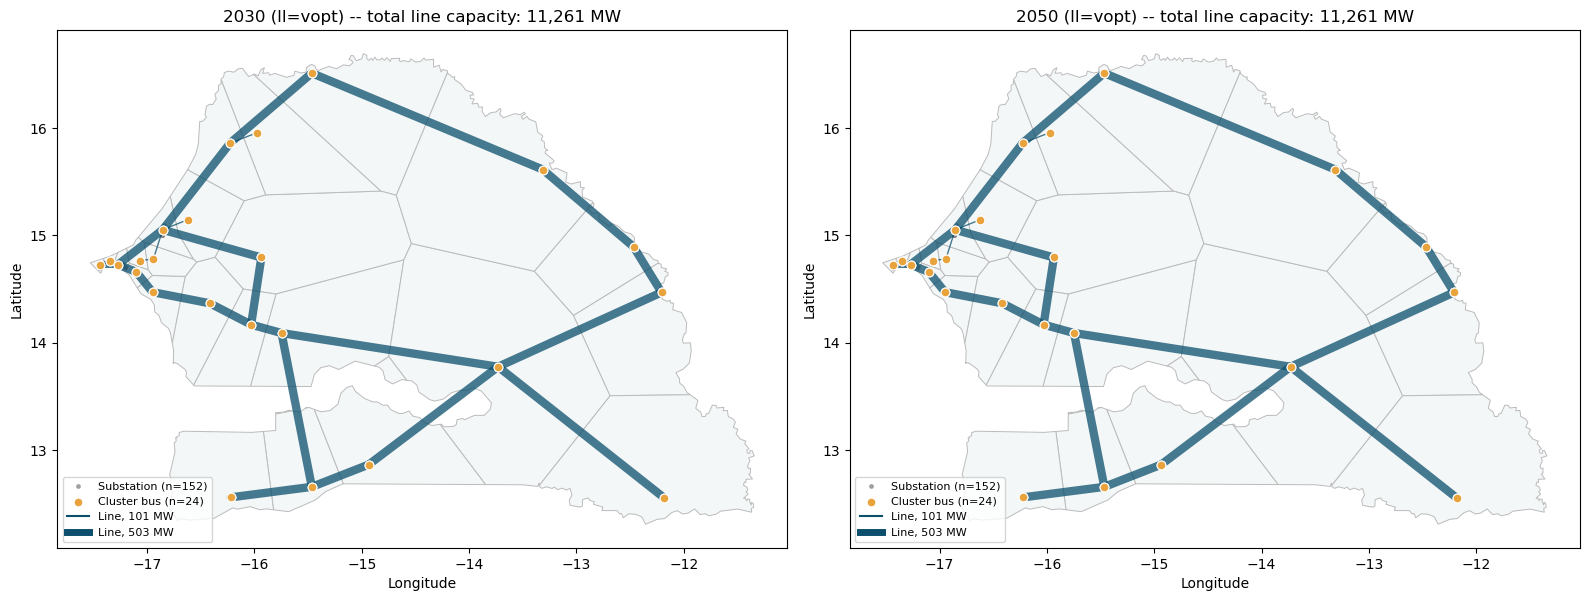

In [2]:
import matplotlib.lines as mlines

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for ax, year in zip(axes, [2030, 2050]):
    n = networks.get(("bess", year, "vopt"))
    if n is None:
        ax.set_title(f"{year} (not available)")
        ax.axis("off")
        continue

    regions = gpd.read_file(f"resources/LP_bess_{year}/bus_regions/regions_onshore_elec_s_24.geojson")
    subs = gpd.read_file(f"resources/LP_bess_{year}/osm/clean/all_clean_substations.geojson")

    regions.plot(ax=ax, color="#f4f7f8", edgecolor="#bbb", linewidth=0.7, zorder=0)
    ax.scatter(subs.geometry.x, subs.geometry.y, s=6, color="#888888", alpha=0.7, zorder=1,
               label=f"Substation (n={len(subs)})")

    cap_min, cap_max = n.lines.s_nom_opt.min(), n.lines.s_nom_opt.max()
    for _, line in n.lines.iterrows():
        x0, y0 = n.buses.loc[line.bus0, ["x", "y"]]
        x1, y1 = n.buses.loc[line.bus1, ["x", "y"]]
        width = 1 + 5 * (line.s_nom_opt - cap_min) / (cap_max - cap_min) if cap_max > cap_min else 2
        ax.plot([x0, x1], [y0, y1], color=COL["bess"], linewidth=width, alpha=0.75, zorder=2,
                solid_capstyle="round")

    ax.scatter(n.buses.x, n.buses.y, s=40, color=COL["no_bess"], edgecolor="white",
               linewidth=0.8, zorder=3, label=f"Cluster bus (n={len(n.buses[n.buses.carrier=='AC'])})")

    total_cap = n.lines.s_nom_opt.sum()
    ax.set_title(f"{year} (ll=vopt) -- total line capacity: {total_cap:,.0f} MW")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_aspect("equal")

    thin = mlines.Line2D([], [], color=COL["bess"], linewidth=1.5, label=f"Line, {cap_min:.0f} MW")
    thick = mlines.Line2D([], [], color=COL["bess"], linewidth=5, label=f"Line, {cap_max:.0f} MW")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [thin, thick], loc="lower left", fontsize=8)

plt.tight_layout()
plt.savefig("figures/results_analysis/transmission_network_2030_2050.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading this**: the two maps look essentially identical, and that's the
point, not a rendering issue -- total line capacity is 11,261.1 MW in 2030 and
11,261.2 MW in 2050 (a rounding-level difference), confirming the earlier finding
directly: with BESS in the system, `ll=vopt` (transmission expansion allowed) and
`ll=v1.0` (capped at today's level) produce identical total system cost in every
year through 2050 -- the optimizer never chooses to expand the grid at all, even as
demand more than doubles, because battery substitutes for that need instead. The
`no_bess` scenario is where transmission expansion actually happens (see the
total-system-cost comparison earlier) -- worth a follow-up version of this map
comparing `bess` vs `no_bess` at 2050 specifically, if useful.

## 0c. Transmission network — `bess` vs `no_bess`, 2050 (ll=vopt)

Same three layers as above, but now holding year fixed (2050) and `ll` fixed
(`vopt`, transmission expansion allowed) while varying the BESS scenario -- this is
where the interesting difference actually shows up, unlike the 2030-vs-2050
comparison above.

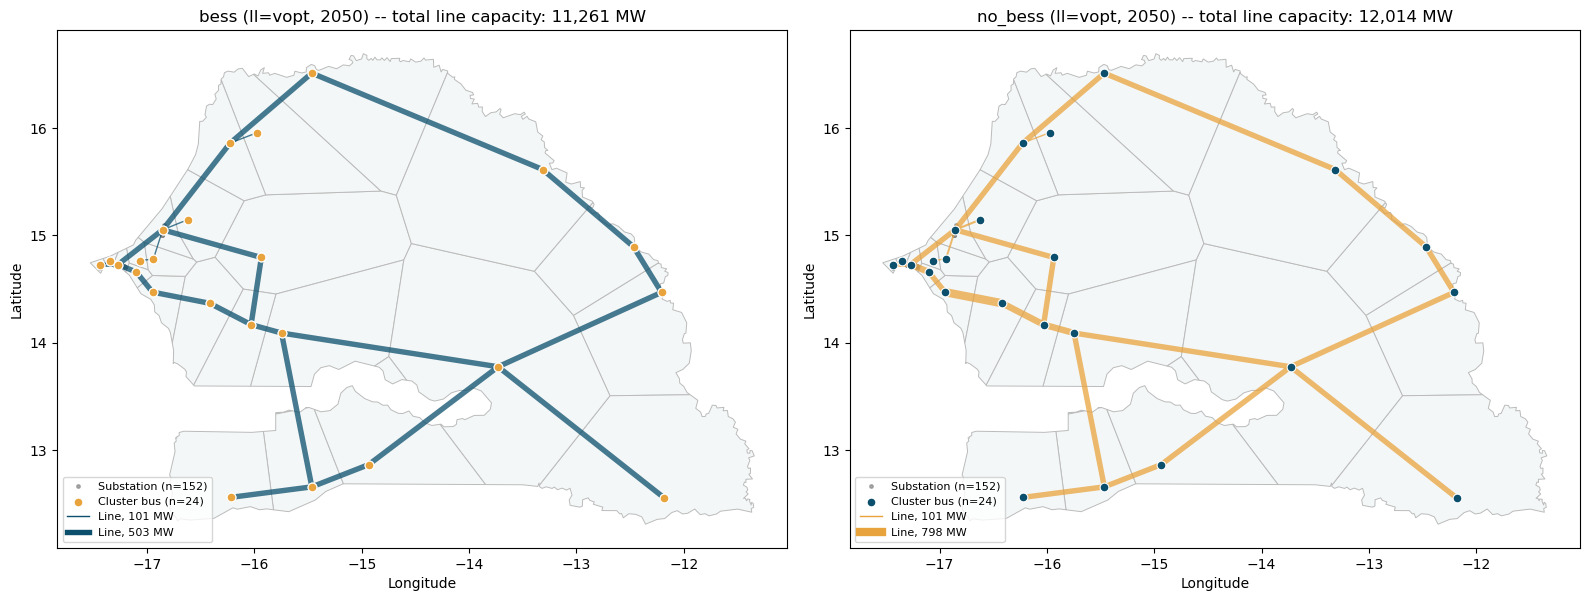

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for ax, scen in zip(axes, SCENARIOS):
    n = networks.get((scen, 2050, "vopt"))
    if n is None:
        ax.set_title(f"{scen} (not available)")
        ax.axis("off")
        continue

    regions = gpd.read_file(f"resources/LP_{scen}_2050/bus_regions/regions_onshore_elec_s_24.geojson")
    subs = gpd.read_file(f"resources/LP_{scen}_2050/osm/clean/all_clean_substations.geojson")

    regions.plot(ax=ax, color="#f4f7f8", edgecolor="#bbb", linewidth=0.7, zorder=0)
    ax.scatter(subs.geometry.x, subs.geometry.y, s=6, color="#888888", alpha=0.7, zorder=1,
               label=f"Substation (n={len(subs)})")

    # shared capacity scale across both panels so line thickness is directly comparable
    cap_min = min(networks[(s, 2050, "vopt")].lines.s_nom_opt.min() for s in SCENARIOS if (s, 2050, "vopt") in networks)
    cap_max = max(networks[(s, 2050, "vopt")].lines.s_nom_opt.max() for s in SCENARIOS if (s, 2050, "vopt") in networks)
    for _, line in n.lines.iterrows():
        x0, y0 = n.buses.loc[line.bus0, ["x", "y"]]
        x1, y1 = n.buses.loc[line.bus1, ["x", "y"]]
        width = 1 + 5 * (line.s_nom_opt - cap_min) / (cap_max - cap_min) if cap_max > cap_min else 2
        ax.plot([x0, x1], [y0, y1], color=COL[scen], linewidth=width, alpha=0.75, zorder=2,
                solid_capstyle="round")

    ax.scatter(n.buses.x, n.buses.y, s=40, color=COL["no_bess"] if scen == "bess" else COL["bess"],
               edgecolor="white", linewidth=0.8, zorder=3,
               label=f"Cluster bus (n={len(n.buses[n.buses.carrier=='AC'])})")

    total_cap = n.lines.s_nom_opt.sum()
    ax.set_title(f"{scen} (ll=vopt, 2050) -- total line capacity: {total_cap:,.0f} MW")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_aspect("equal")

    # legend reflects THIS panel's own actual min/max (not the shared cap_min/cap_max used
    # only for the width formula above) -- otherwise a panel whose own lines never reach the
    # other panel's max would show a legend entry for a line capacity that doesn't exist on
    # its own map.
    panel_min, panel_max = n.lines.s_nom_opt.min(), n.lines.s_nom_opt.max()
    panel_min_width = 1 + 5 * (panel_min - cap_min) / (cap_max - cap_min) if cap_max > cap_min else 2
    panel_max_width = 1 + 5 * (panel_max - cap_min) / (cap_max - cap_min) if cap_max > cap_min else 2
    thin = mlines.Line2D([], [], color=COL[scen], linewidth=panel_min_width, label=f"Line, {panel_min:.0f} MW")
    thick = mlines.Line2D([], [], color=COL[scen], linewidth=panel_max_width, label=f"Line, {panel_max:.0f} MW")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [thin, thick], loc="lower left", fontsize=8)

plt.tight_layout()
plt.savefig("figures/results_analysis/transmission_network_bess_vs_no_bess_2050.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading this**: `no_bess` builds 12,014 MW of total line capacity vs. `bess`'s
11,261 MW -- a real ~753 MW of additional transmission that only gets built when
there's no battery available to substitute for it. Look for visibly thicker lines on
the `no_bess` side, particularly wherever the network needs to move solar-heavy
generation toward the demand centre -- that's the capacity BESS is displacing in the
`bess` case. This is the direct visual counterpart to the €43.2M/yr total-system-cost
gap between `no_bess` `vopt` and `v1.0` found earlier: this map shows where that
extra spending actually goes.

### 0c (zoomed) — `bess` vs `no_bess`, 2050, Dakar and the western clusters

Same map and capacity-width scale as directly above, zoomed to the same Dakar-area
bounding box used in Section 0e, since that's where the cluster/line density is
highest and any difference between the two panels is easiest to actually see.

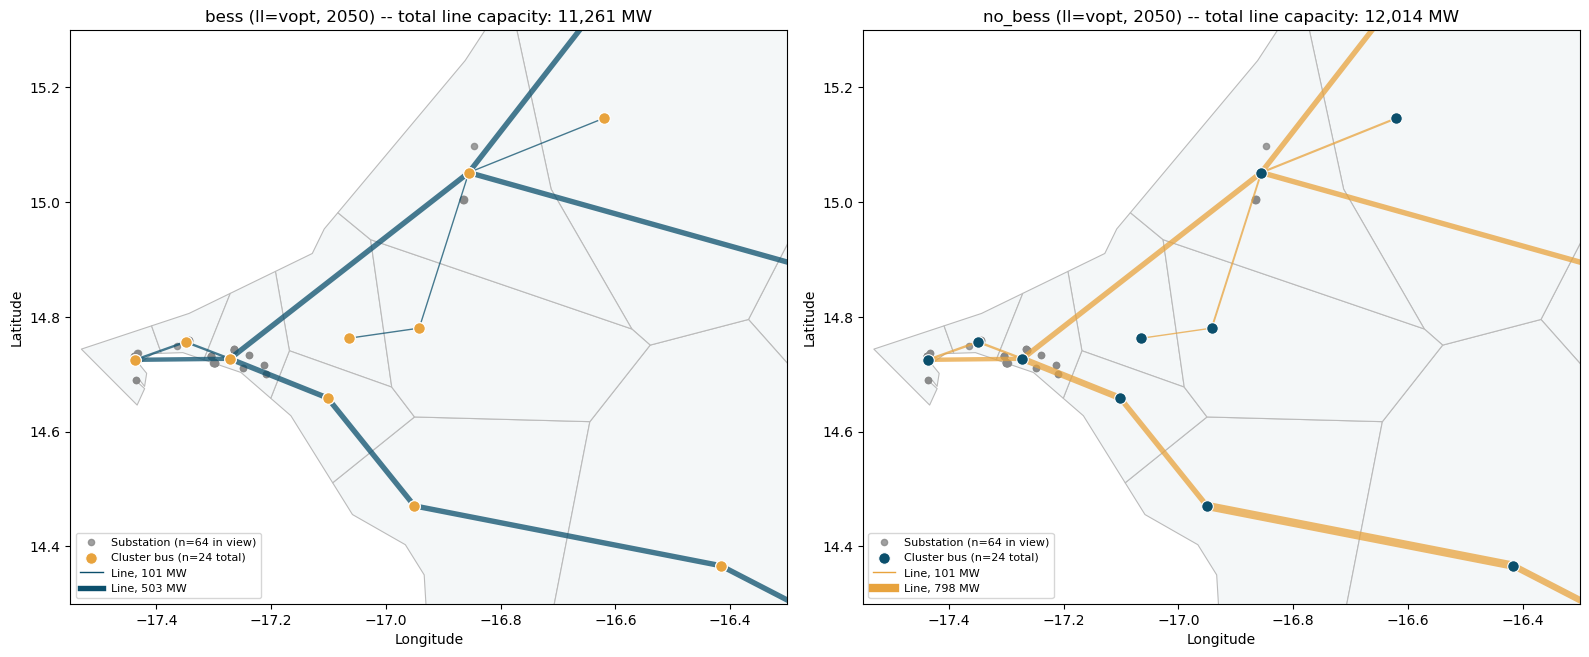

In [4]:
ZOOM_LON = (-17.55, -16.3)
ZOOM_LAT = (14.3, 15.3)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for ax, scen in zip(axes, SCENARIOS):
    n = networks.get((scen, 2050, "vopt"))
    if n is None:
        ax.set_title(f"{scen} (not available)")
        ax.axis("off")
        continue

    regions_z = gpd.read_file(f"resources/LP_{scen}_2050/bus_regions/regions_onshore_elec_s_24.geojson")
    subs_z = gpd.read_file(f"resources/LP_{scen}_2050/osm/clean/all_clean_substations.geojson")
    subs_z = subs_z.cx[ZOOM_LON[0]:ZOOM_LON[1], ZOOM_LAT[0]:ZOOM_LAT[1]]

    regions_z.plot(ax=ax, color="#f4f7f8", edgecolor="#bbb", linewidth=0.8, zorder=0)
    ax.scatter(subs_z.geometry.x, subs_z.geometry.y, s=20, color="#888888", alpha=0.8, zorder=1,
               label=f"Substation (n={len(subs_z)} in view)")

    cap_min = min(networks[(s, 2050, "vopt")].lines.s_nom_opt.min() for s in SCENARIOS if (s, 2050, "vopt") in networks)
    cap_max = max(networks[(s, 2050, "vopt")].lines.s_nom_opt.max() for s in SCENARIOS if (s, 2050, "vopt") in networks)
    for _, line in n.lines.iterrows():
        x0, y0 = n.buses.loc[line.bus0, ["x", "y"]]
        x1, y1 = n.buses.loc[line.bus1, ["x", "y"]]
        width = 1 + 5 * (line.s_nom_opt - cap_min) / (cap_max - cap_min) if cap_max > cap_min else 2
        ax.plot([x0, x1], [y0, y1], color=COL[scen], linewidth=width, alpha=0.75, zorder=2,
                solid_capstyle="round")

    ax.scatter(n.buses.x, n.buses.y, s=70, color=COL["no_bess"] if scen == "bess" else COL["bess"],
               edgecolor="white", linewidth=0.8, zorder=3,
               label=f"Cluster bus (n={len(n.buses[n.buses.carrier=='AC'])} total)")

    total_cap = n.lines.s_nom_opt.sum()
    ax.set_xlim(*ZOOM_LON)
    ax.set_ylim(*ZOOM_LAT)
    ax.set_title(f"{scen} (ll=vopt, 2050) -- total line capacity: {total_cap:,.0f} MW")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_aspect("equal")

    panel_min, panel_max = n.lines.s_nom_opt.min(), n.lines.s_nom_opt.max()
    panel_min_width = 1 + 5 * (panel_min - cap_min) / (cap_max - cap_min) if cap_max > cap_min else 2
    panel_max_width = 1 + 5 * (panel_max - cap_min) / (cap_max - cap_min) if cap_max > cap_min else 2
    thin = mlines.Line2D([], [], color=COL[scen], linewidth=panel_min_width, label=f"Line, {panel_min:.0f} MW")
    thick = mlines.Line2D([], [], color=COL[scen], linewidth=panel_max_width, label=f"Line, {panel_max:.0f} MW")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [thin, thick], loc="lower left", fontsize=8)

plt.tight_layout()
plt.savefig("figures/results_analysis/transmission_network_bess_vs_no_bess_2050_dakar_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

## 0d. Senegal transmission network — by voltage level

The clustered 24-node model used everywhere else in this notebook only carries a
single voltage class -- checked directly: all 27 lines show `v_nom = 225 kV`,
identical across every scenario and year, because network simplification/clustering
absorbs the lower-voltage sub-transmission lines into the 225 kV backbone
representation. A kV-coded map of *that* network would just be one flat colour, so
this map instead uses the **patched** base-network line geometry
(`base_network/all_lines_build_network.geojson`) rather than the raw OSM extract --
`custom_rules/patch_transmission.smk` / `scripts/patch_transmission.py` corrects
several known errors in Senegal's raw OSM transmission data before this stage: 4
missing lines, one line that incorrectly runs straight through an intermediate
substation without stopping (split into two correct segments), and one missing
substation. The patched network: 30 lines (20 at 225 kV, 10 at 90 kV), 29 buses.
This is real infrastructure, not a solved-network output, so it's identical across
scenario/year and shown once, not as a 2030-vs-2050 or bess-vs-no_bess
comparison.

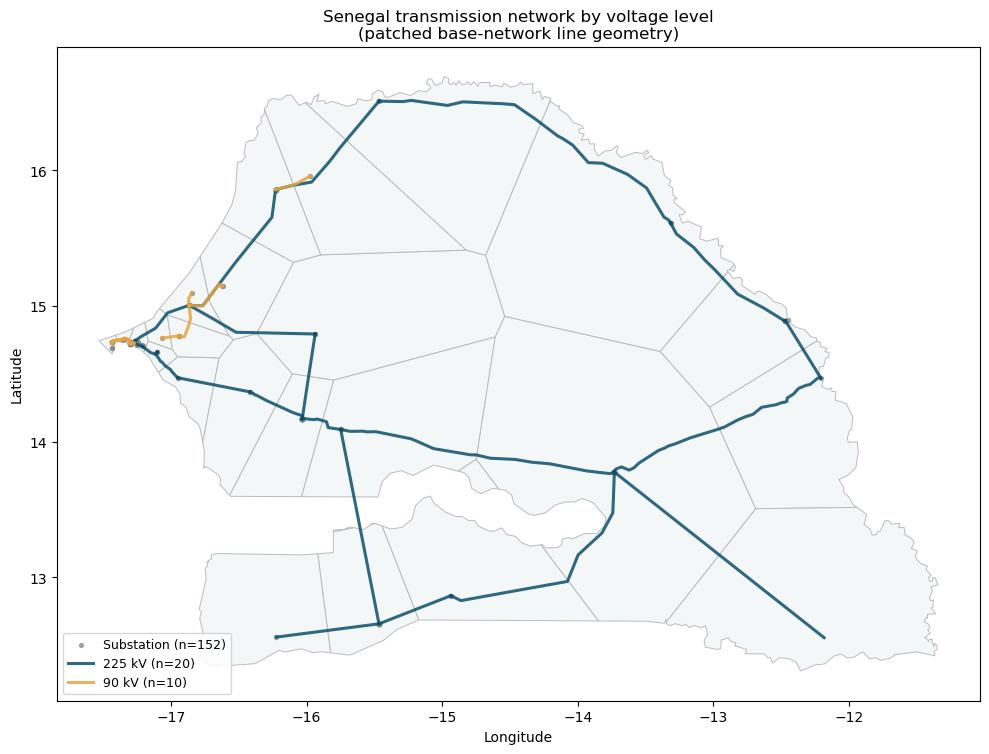

In [5]:
lines_patched = gpd.read_file("resources/LP_bess_2030/base_network/all_lines_build_network.geojson")
subs = gpd.read_file("resources/LP_bess_2030/osm/clean/all_clean_substations.geojson")
regions = gpd.read_file("resources/LP_bess_2030/bus_regions/regions_onshore_elec_s_24.geojson")

VOLTAGE_COLORS = {225000: COL["bess"], 90000: COL["no_bess"]}

fig, ax = plt.subplots(figsize=(10, 10))
regions.plot(ax=ax, color="#f4f7f8", edgecolor="#bbb", linewidth=0.7, zorder=0)
ax.scatter(subs.geometry.x, subs.geometry.y, s=8, color="#888888", alpha=0.7, zorder=1,
           label=f"Substation (n={len(subs)})")

for voltage, color in VOLTAGE_COLORS.items():
    subset = lines_patched[lines_patched.voltage == voltage]
    plotted_label = False
    for geom in subset.geometry:
        # all geometries here are MultiLineString (even single-segment lines) --
        # iterate over the constituent parts rather than calling .xy directly
        parts = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
        for part in parts:
            xs, ys = part.xy
            ax.plot(xs, ys, color=color, linewidth=2.2, alpha=0.85, zorder=2,
                    label=f"{voltage // 1000} kV (n={len(subset)})" if not plotted_label else "_nolegend_")
            plotted_label = True

ax.set_title("Senegal transmission network by voltage level\n(patched base-network line geometry)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.savefig("figures/results_analysis/transmission_network_by_voltage.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading this**: the 225 kV backbone (dark blue) is what actually survives
into the capacity-expansion model used throughout this notebook -- the 90 kV lines
(orange) represent real sub-transmission infrastructure that the clustered model
doesn't distinguish. Worth keeping in mind as a modelling simplification when
interpreting the earlier capacity maps: they describe expansion of the 225 kV
backbone only, not the full real network.

## 0e. Zoomed in — Dakar and the western clusters

Same patched-network, by-voltage layers as above, zoomed to the Dakar peninsula and
surrounding western clusters (west of -16.3 deg longitude), where the real
substation and 90 kV sub-transmission density is highest -- 62 of 152 substations
and 12 of 29 base-network buses sit in this corner alone.

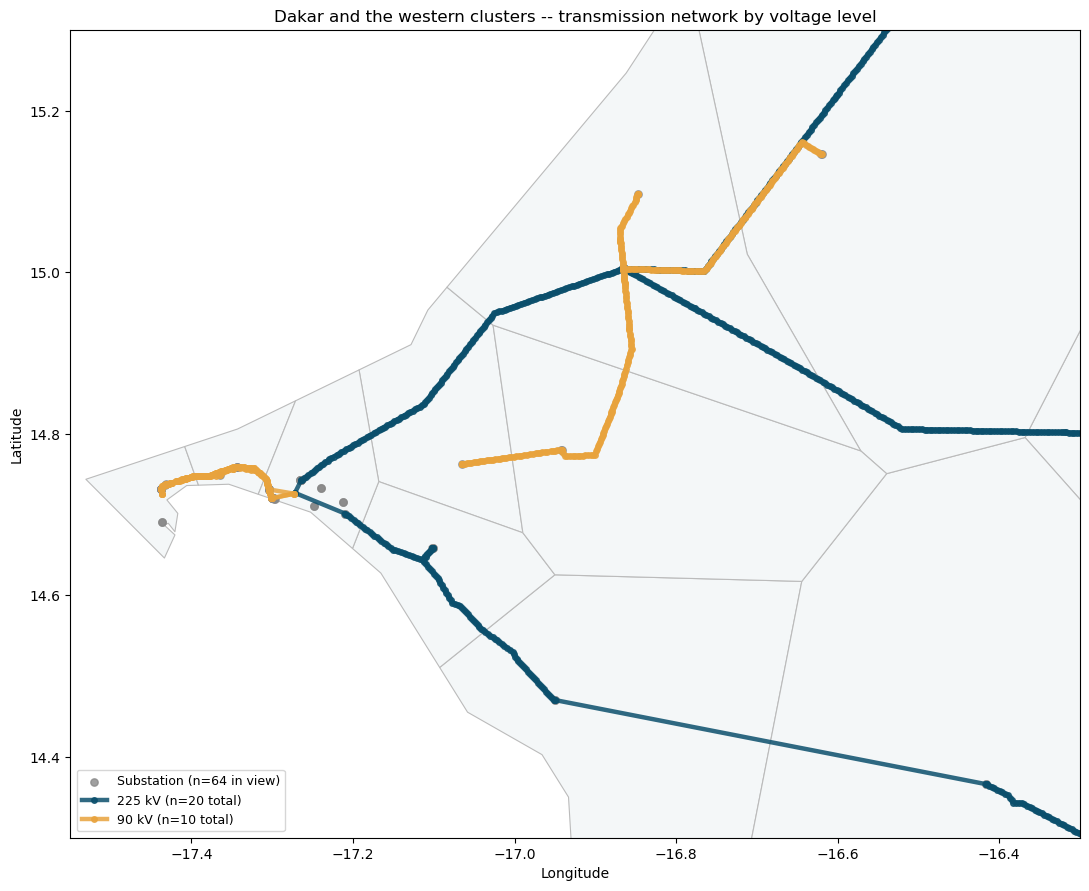

In [6]:
ZOOM_LON = (-17.55, -16.3)
ZOOM_LAT = (14.3, 15.3)

fig, ax = plt.subplots(figsize=(11, 10))
regions.plot(ax=ax, color="#f4f7f8", edgecolor="#bbb", linewidth=0.8, zorder=0)
subs_zoom = subs.cx[ZOOM_LON[0]:ZOOM_LON[1], ZOOM_LAT[0]:ZOOM_LAT[1]]
ax.scatter(subs_zoom.geometry.x, subs_zoom.geometry.y, s=28, color="#888888", alpha=0.8,
           zorder=1, label=f"Substation (n={len(subs_zoom)} in view)")

for voltage, color in VOLTAGE_COLORS.items():
    subset = lines_patched[lines_patched.voltage == voltage]
    plotted_label = False
    for geom in subset.geometry:
        parts = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
        for part in parts:
            xs, ys = part.xy
            ax.plot(xs, ys, color=color, linewidth=3.2, alpha=0.85, zorder=2, marker="o",
                    markersize=4,
                    label=f"{voltage // 1000} kV (n={len(subset)} total)" if not plotted_label else "_nolegend_")
            plotted_label = True

ax.set_xlim(*ZOOM_LON)
ax.set_ylim(*ZOOM_LAT)
ax.set_title("Dakar and the western clusters -- transmission network by voltage level")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.savefig("figures/results_analysis/transmission_network_dakar_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading this**: this is where nearly all of Senegal's 90 kV sub-transmission
sits -- the dense, tightly-spaced substation cluster around Dakar, distinct from the
long-haul 225 kV lines radiating out to the rest of the country seen in the full map
above.

## 0f. Installed capacity mix per node — 2050 (bess, vopt)

Same total-capacity-per-node idea as before, but now as a pie chart at each of the
24 cluster buses showing the **technology mix**, not just the total -- pie area
scales with total MW at that node (radius ~ sqrt(total MW), so area is fair), wedges
use the same carrier colours as the installed-capacity-through-years chart earlier.
Nodes below 30 MW total are dropped from the pie rendering (too small to render a
meaningful wedge split) but still show as a small grey dot.

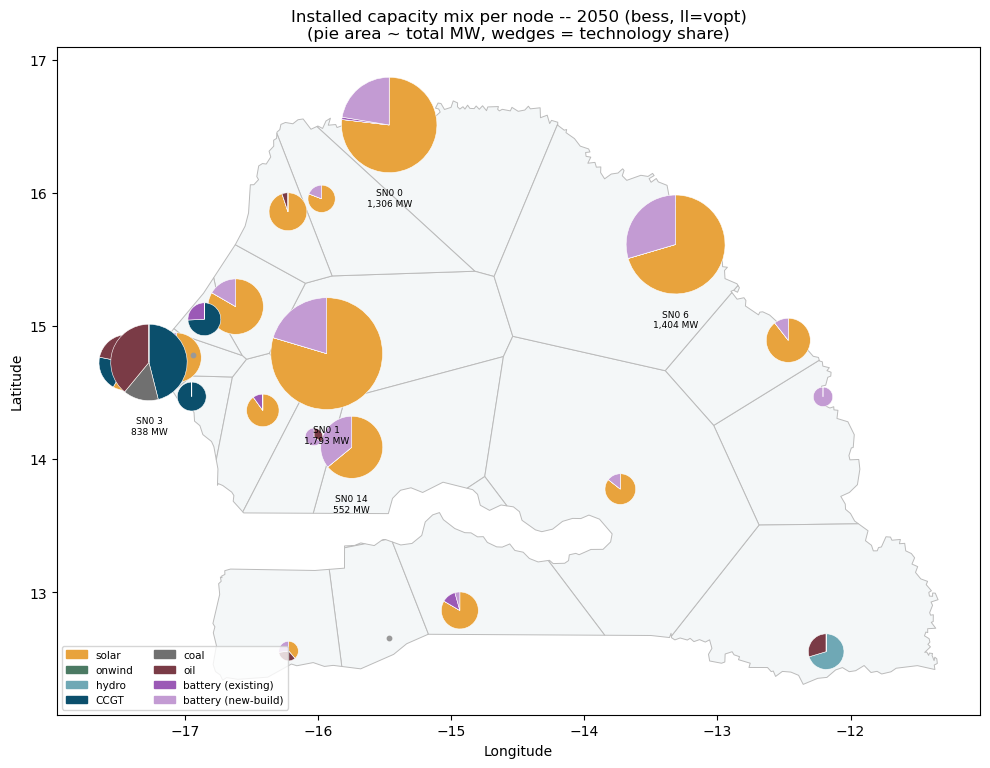

carrier,solar,onwind,offwind-ac,offwind-dc,hydro,CCGT,OCGT,coal,oil,biomass,battery (existing),battery (new-build),total_MW,avg_load_MW
Bus,,,,,,,,,,,,,,
SN0 1,1427.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,365.6,1792.8,172.2
SN0 6,988.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,415.0,1403.7,74.8
SN0 0,1003.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,292.5,1305.8,71.4
SN0 3,0.0,0.0,0.0,0.0,0.0,386.0,0.0,125.0,327.0,0.0,0.0,0.0,838.0,134.6
SN0 14,353.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,198.6,552.5,130.3
SN0 16,262.5,0.0,0.0,0.0,0.0,90.0,0.0,0.0,98.6,0.0,0.0,0.0,451.1,57.4
SN0 17,367.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,73.2,440.5,90.1
SN0 18,261.4,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,61.0,352.4,63.6
SN0 19,249.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.4,278.8,15.9


In [7]:
n = networks.get(("bess", 2050, "vopt"))

gen_by_carrier = n.generators[n.generators.carrier.isin(GEN_CARRIERS)].groupby(
    ["bus", "carrier"]).p_nom_opt.sum().unstack(fill_value=0.0)
hydro_by_bus = n.storage_units[n.storage_units.carrier == "hydro"].groupby("bus").p_nom_opt.sum()
batt_exist_by_bus = n.storage_units[n.storage_units.carrier == "battery"].groupby("bus").p_nom_opt.sum()
batt_new_by_bus = n.links[n.links.carrier == "battery charger"].groupby("bus0").p_nom_opt.sum()

mix = gen_by_carrier.reindex(columns=GEN_CARRIERS, fill_value=0.0)
mix["hydro"] = hydro_by_bus
mix["battery (existing)"] = batt_exist_by_bus
mix["battery (new-build)"] = batt_new_by_bus
mix = mix.reindex(n.buses[n.buses.carrier == "AC"].index).fillna(0.0)
mix = mix.reindex(columns=CAP_ORDER, fill_value=0.0)

total_cap = mix.sum(axis=1)
load_avg = n.loads_t.p_set.mean().reindex(mix.index).fillna(0.0)

fig, ax = plt.subplots(figsize=(10, 11))
regions.plot(ax=ax, color="#f4f7f8", edgecolor="#bbb", linewidth=0.7, zorder=0)

max_radius_deg = 0.42
radii = (total_cap / total_cap.max()).pow(0.5) * max_radius_deg

for bus in mix.index:
    x0, y0 = n.buses.at[bus, "x"], n.buses.at[bus, "y"]
    r = radii[bus]
    if total_cap[bus] < 30 or r <= 0:
        ax.scatter([x0], [y0], s=10, color="#999999", zorder=2)
        continue
    shares = mix.loc[bus]
    shares = shares[shares > 0]
    theta0 = 90.0
    for carrier, val in shares.items():
        frac = val / total_cap[bus]
        theta1 = theta0 - frac * 360
        wedge = mpatches.Wedge((x0, y0), r, min(theta0, theta1), max(theta0, theta1),
                                facecolor=CAP_COLORS.get(carrier, "#999999"), edgecolor="white",
                                linewidth=0.4, zorder=2)
        ax.add_patch(wedge)
        theta0 = theta1
    if total_cap[bus] > 500:
        ax.annotate(f"{bus}\n{total_cap[bus]:,.0f} MW", (x0, y0 - r - 0.12),
                    fontsize=6.5, ha="center", va="top", zorder=3)

legend_handles = [mpatches.Patch(color=CAP_COLORS[c], label=c) for c in CAP_ORDER if mix[c].sum() > 0]
ax.legend(handles=legend_handles, loc="lower left", fontsize=7.5, ncol=2)

ax.set_title("Installed capacity mix per node -- 2050 (bess, ll=vopt)\n(pie area ~ total MW, wedges = technology share)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("figures/results_analysis/installed_capacity_mix_per_node_2050.png", dpi=150, bbox_inches="tight")
plt.show()

summary = mix.copy()
summary["total_MW"] = total_cap
summary["avg_load_MW"] = load_avg
display(summary.sort_values("total_MW", ascending=False).round(1))

**Reading this**: the large rural nodes (SN0 6, SN0 1, SN0 0) are overwhelmingly
solar-and-battery (orange + purple wedges dominate), confirming the land-availability
story directly -- these nodes aren't just *bigger*, they're built almost entirely out
of the technologies that need cheap land. SN0 3 (Dakar) stands out as the one large
node that's a completely different colour mix -- mostly existing thermal (dark blue/
grey/maroon), not renewables, consistent with it being dominated by the Cap Des
Biches legacy entries flagged earlier rather than any new siting decision.

## 0g. Solar land-use eligibility per node

`Generator.p_nom_max` for the `solar` carrier -- the land-use-based ceiling on how
much utility-scale solar can physically be sited at each node, independent of
whether the optimizer actually chooses to build there. This is upstream of every
other map in this section: it's the underlying constraint that explains why solar
(and the battery that follows it) concentrates in a handful of rural nodes rather
than near Dakar's demand. Static input data, not a solved-network output, so shown
once rather than per year/scenario.

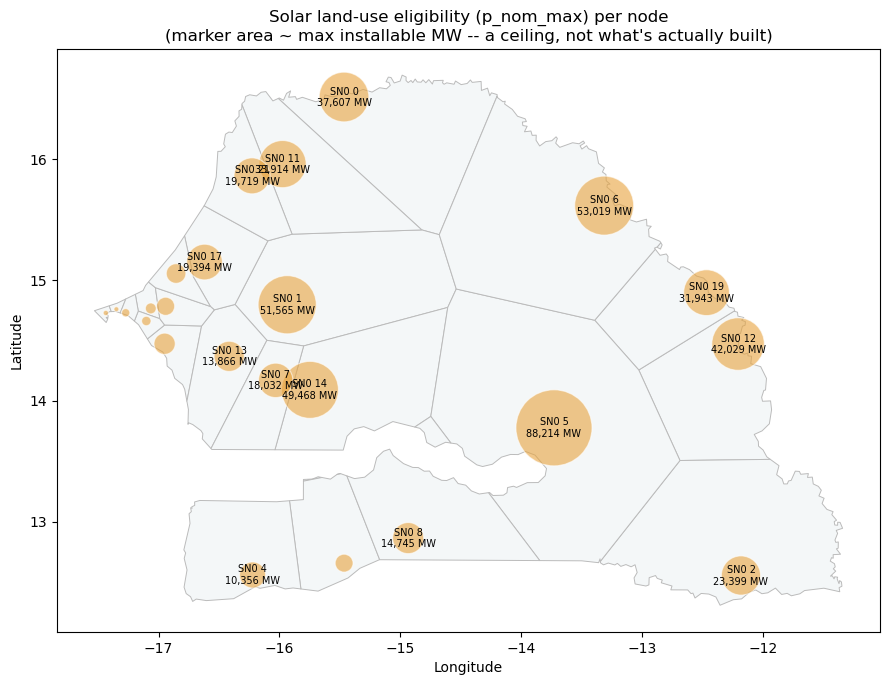

Bus
SN0 5     88214.0
SN0 6     53019.0
SN0 1     51565.0
SN0 14    49468.0
SN0 12    42029.0
SN0 0     37607.0
SN0 11    33914.0
SN0 19    31943.0
SN0 2     23399.0
SN0 21    19719.0
SN0 17    19394.0
SN0 7     18032.0
SN0 8     14745.0
SN0 13    13866.0
SN0 4     10356.0
SN0 10     6875.0
SN0 9      5867.0
SN0 22     5016.0
SN0 15     4883.0
SN0 18     1811.0
SN0 20     1351.0
SN0 3      1043.0
SN0 16      421.0
SN0 23      373.0
Name: solar_p_nom_max_MW, dtype: float64

In [8]:
solar_max = n.generators[n.generators.carrier == "solar"].set_index("bus").p_nom_max
solar_max = solar_max.reindex(n.buses[n.buses.carrier == "AC"].index).fillna(0.0)

fig, ax = plt.subplots(figsize=(9, 10))
regions.plot(ax=ax, color="#f4f7f8", edgecolor="#bbb", linewidth=0.7, zorder=0)

sizes = (solar_max / solar_max.max()).clip(lower=0) * 3000
ax.scatter(n.buses.loc[solar_max.index, "x"], n.buses.loc[solar_max.index, "y"],
           s=sizes, color=CAP_COLORS["solar"], alpha=0.6, edgecolor="white", linewidth=0.8, zorder=2)

for bus in solar_max.index:
    if solar_max[bus] > 10_000:
        ax.annotate(f"{bus}\n{solar_max[bus]:,.0f} MW", (n.buses.at[bus, 'x'], n.buses.at[bus, 'y']),
                    fontsize=7, ha="center", va="center", zorder=3)

ax.set_title("Solar land-use eligibility (p_nom_max) per node\n(marker area ~ max installable MW -- a ceiling, not what's actually built)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("figures/results_analysis/solar_eligibility_per_node.png", dpi=150, bbox_inches="tight")
plt.show()

display(solar_max.sort_values(ascending=False).rename("solar_p_nom_max_MW").round(0))

**Reading this**: compare directly against the capacity-mix pie chart above --
the ranking is nearly identical. SN0 6, SN0 1, SN0 0, and SN0 14 have by far the
largest land-use ceilings (37,000-53,000 MW each), while every Dakar-area node caps
out under ~7,000 MW and several under 500 MW. The optimizer isn't discovering this
pattern through some complex trade-off -- it's mostly just following a land-
availability constraint that was fixed long before the solve even started.

## 1. BESS capacity and locations — 2050 (vopt)

Two representations of battery storage exist in the model: **existing/committed**
capacity (`StorageUnit`, Senegal's real already-installed batteries) and **new-build**
capacity (`Store` + charger/discharger `Link` pair, sized endogenously by the
optimizer). Both are shown.

Existing (committed) battery power : 89.0 MW
New-build battery power            : 1,603.8 MW
New-build battery energy           : 8,665.8 MWh
New-build implied duration          : 5.40 h


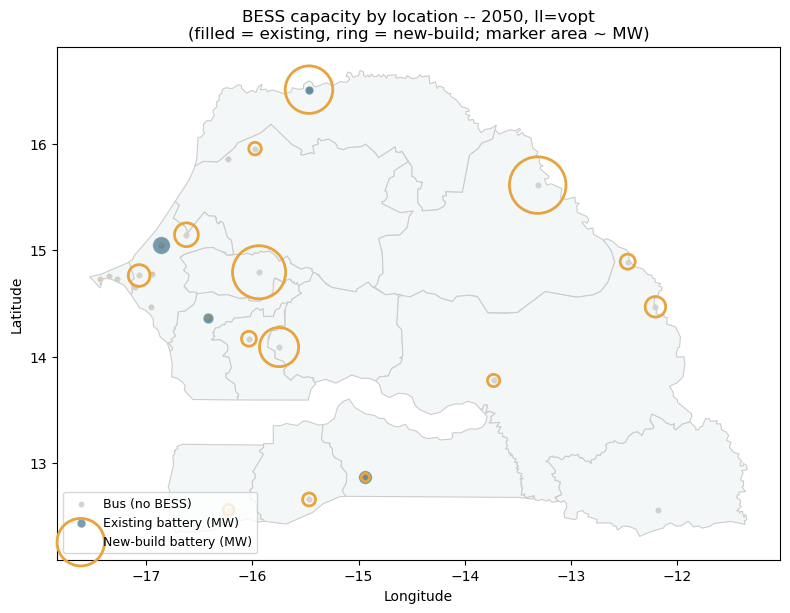

In [9]:
n = networks.get(("bess", 2050, "vopt"))

if n is None:
    print("results/LP_bess_2050 (vopt) not available yet -- re-run this cell once that config finishes.")
else:
    # Existing (committed) battery -- StorageUnit
    su = n.storage_units[n.storage_units.carrier == "battery"]
    su_cap_mw = su.groupby("bus")["p_nom_opt"].sum()

    # New-build battery -- Store (energy, MWh) + charger Link (power, MW)
    store = n.stores[n.stores.carrier == "battery"]
    store_ac_bus = store.bus.str.replace(" battery", "", regex=False)
    new_cap_mwh = store.set_index(store_ac_bus)["e_nom_opt"]

    charger = n.links[n.links.carrier == "battery charger"]
    new_cap_mw = charger.groupby("bus0")["p_nom_opt"].sum()

    print(f"Existing (committed) battery power : {su_cap_mw.sum():,.1f} MW")
    print(f"New-build battery power            : {new_cap_mw.sum():,.1f} MW")
    new_cap_mwh_total = new_cap_mwh.sum()
    print(f"New-build battery energy           : {new_cap_mwh_total:,.1f} MWh")
    if new_cap_mw.sum() > 0:
        print(f"New-build implied duration          : {new_cap_mwh.sum() / new_cap_mw.sum():.2f} h")

    # Map
    try:
        country = gpd.read_file(f"resources/LP_bess_2050/shapes/gadm_shapes.geojson")
    except Exception:
        country = None

    fig, ax = plt.subplots(figsize=(8, 9))
    if country is not None:
        country.plot(ax=ax, color="#f4f7f8", edgecolor="#ccc", linewidth=0.8, zorder=0)

    buses = n.buses
    ax.scatter(buses.x, buses.y, s=10, color="lightgray", zorder=1, label="Bus (no BESS)")

    existing_plotted = False
    for bus, cap in su_cap_mw.items():
        if bus in buses.index and cap > 0:
            ax.scatter(buses.at[bus, "x"], buses.at[bus, "y"], s=cap * 4, color=COL["bess"],
                       alpha=0.55, zorder=2, edgecolor="white", linewidth=0.5,
                       label="Existing battery (MW)" if not existing_plotted else "_nolegend_")
            existing_plotted = True

    new_plotted = False
    for bus, cap in new_cap_mw.items():
        if bus in buses.index and cap > 0:
            ax.scatter(buses.at[bus, "x"], buses.at[bus, "y"], s=cap * 4, facecolors="none",
                       edgecolors=COL["no_bess"], linewidth=2, zorder=3,
                       label="New-build battery (MW)" if not new_plotted else "_nolegend_")
            new_plotted = True

    ax.set_title("BESS capacity by location -- 2050, ll=vopt\n(filled = existing, ring = new-build; marker area ~ MW)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.legend(loc="lower left", fontsize=9)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.savefig("figures/results_analysis/bess_map_2050_vopt.png", dpi=150)
    plt.show()

## 1b. Installed capacity through the years (vopt)

Stacked installed capacity by carrier, `bess` vs `no_bess`, **2025** and 2030-2050.
2025 has no solved network (no demand-projection data available for that year, see
overview) -- it's the real existing/committed fleet straight from `powerplants.csv`
(no optimization), included here purely as the pre-expansion starting point. 2030
onward uses `p_nom_opt` (MW) from the solved networks; existing battery and hydro are
`StorageUnit.p_nom_opt`; new-build battery power is the charger `Link.p_nom_opt`. The
`load shedding` "generator" (an unlimited-capacity accounting device, not real
capacity) is excluded throughout.

**Known data-quality caveat affecting the 2025 bar specifically**: `Cap Des Biches`
appears as two separate powerplantmatching entries -- an "Oil" unit at 327 MW and a
"CCGT" unit at 386 MW, dated as already commissioned in 2013 and 2016 respectively.
Cross-checked against the actual operators (ContourGlobal, West Africa Energy SA) and
Global Energy Monitor: the real existing HFO unit is only **86 MW** (commissioned
2016), and the 366 MW gas-fired combined-cycle unit is **still under construction**
(planned commissioning 2026, not yet operating). So this single site is currently
overstated by roughly 630 MW in the "existing 2025" fleet below -- a data error in
the underlying source database, not a modelling choice, and not yet corrected here.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


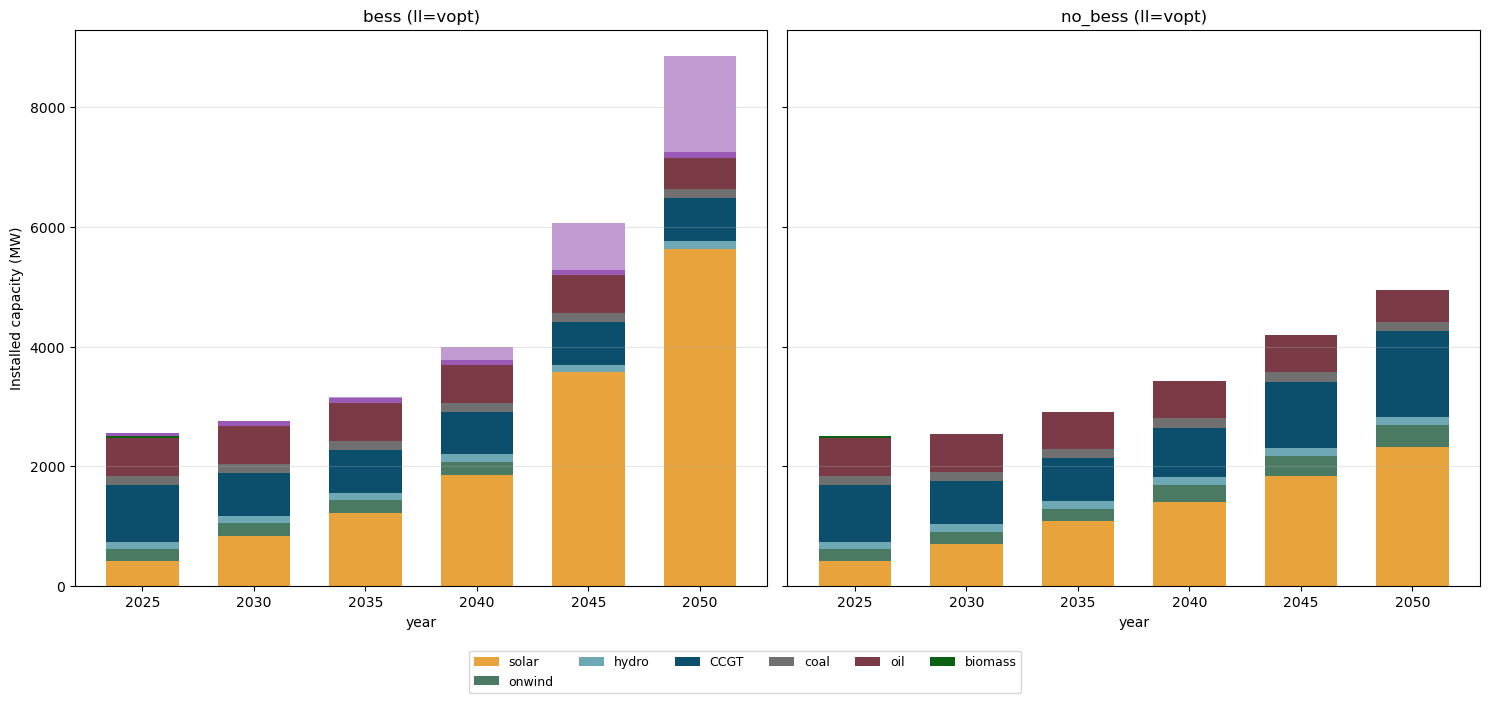

In [10]:
GEN_CARRIERS = ["solar", "onwind", "offwind-ac", "offwind-dc", "CCGT", "OCGT", "coal", "oil", "biomass"]
CAP_COLORS = {
    "solar": "#E8A33D", "onwind": "#4B7A63", "offwind-ac": "#2f5c46", "offwind-dc": "#1f4a37",
    "CCGT": "#0B4F6C", "OCGT": "#4A6572", "coal": "#707070", "oil": "#7A3B46", "biomass": "#0c6013",
    "hydro": "#6FA8B5", "battery (existing)": "#9b59b6", "battery (new-build)": "#c39bd3",
}
CAP_ORDER = ["solar", "onwind", "offwind-ac", "offwind-dc", "hydro", "CCGT", "OCGT", "coal", "oil",
             "biomass", "battery (existing)", "battery (new-build)"]

FUELTYPE_TO_CARRIER = {
    "Solar": "solar", "Wind": "onwind", "Hydro": "hydro", "CCGT": "CCGT", "OCGT": "OCGT",
    "Oil": "oil", "Hard Coal": "coal", "Lignite": "coal", "Solid Biomass": "biomass",
    "Biogas": "biomass", "Battery": "battery (existing)",
}


def installed_capacity(n):
    cap = n.generators[n.generators.carrier.isin(GEN_CARRIERS)].groupby("carrier").p_nom_opt.sum()
    cap["hydro"] = n.storage_units[n.storage_units.carrier == "hydro"].p_nom_opt.sum()
    cap["battery (existing)"] = n.storage_units[n.storage_units.carrier == "battery"].p_nom_opt.sum()
    cap["battery (new-build)"] = n.links[n.links.carrier == "battery charger"].p_nom_opt.sum()
    return cap.reindex(CAP_ORDER).fillna(0.0)


def installed_capacity_2025(scenario):
    path = f"resources/LP_{scenario}_2025/powerplants.csv"
    if not os.path.exists(path):
        print(f"[missing, skipping] {path}")
        return None
    df = pd.read_csv(path)
    carrier = df["Fueltype"].map(FUELTYPE_TO_CARRIER)
    cap = df.groupby(carrier)["Capacity"].sum()
    return cap.reindex(CAP_ORDER).fillna(0.0)


fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
for ax, scen in zip(axes, SCENARIOS):
    data = {}
    cap_2025 = installed_capacity_2025(scen)
    if cap_2025 is not None:
        data[2025] = cap_2025
    for year in YEARS:
        n = networks.get((scen, year, "vopt"))
        if n is None:
            continue
        data[year] = installed_capacity(n)
    cap_df = pd.DataFrame(data).T  # index=year, columns=carrier

    bottom = pd.Series(0.0, index=cap_df.index)
    for carrier in CAP_ORDER:
        if carrier not in cap_df.columns or cap_df[carrier].sum() == 0:
            continue
        ax.bar(cap_df.index.astype(str), cap_df[carrier], bottom=bottom,
               color=CAP_COLORS.get(carrier, "#999999"), label=carrier, width=0.65)
        bottom += cap_df[carrier]

    ax.set_title(f"{scen} (ll=vopt)")
    ax.set_xlabel("year")
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel("Installed capacity (MW)")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=6, fontsize=9)
plt.tight_layout()
plt.savefig("figures/results_analysis/installed_capacity.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading this**: firm thermal capacity (CCGT/coal/oil, the blues/grey/maroon
segments) is essentially flat across the whole horizon -- almost all growth comes
from solar and new-build battery. That's the same pattern underlying both the
reserve-margin decline and the rising electricity-price tail discussed above: peak
demand keeps growing while the firm capacity base doesn't, so the system leans
increasingly on solar+BESS to cover it, and increasingly on the most expensive
thermal units (oil) during the hours that combination can't fully cover.

## 1c. Demand growth through the years

Total annual demand (TWh/yr) and system peak demand (MW), 2030-2050. Demand is an
input to the model (from the GEGIS/SSP2-2.6 projection), not an optimization output,
so it's identical between `bess` and `no_bess` -- confirmed directly
(`loads_t.p_set` compares equal between the two scenarios for every year checked) --
so only one series is shown. **2025 has no data point here either**, for the same
reason it's absent everywhere else in this notebook: the GEGIS/SSP2-2.6 bundle this
pipeline uses has no demand projection for that year at all (only 2030-2050), unlike
the installed-capacity chart above, where a 2025 bar was still possible because that
one draws on the real powerplant fleet directly rather than a solved demand-driven
network.

,total_TWh,peak_MW
year,,
2030,6.70,1059.69
2035,8.10,1280.55
2040,9.51,1501.41
2045,11.87,1876.18
2050,14.23,2252.72


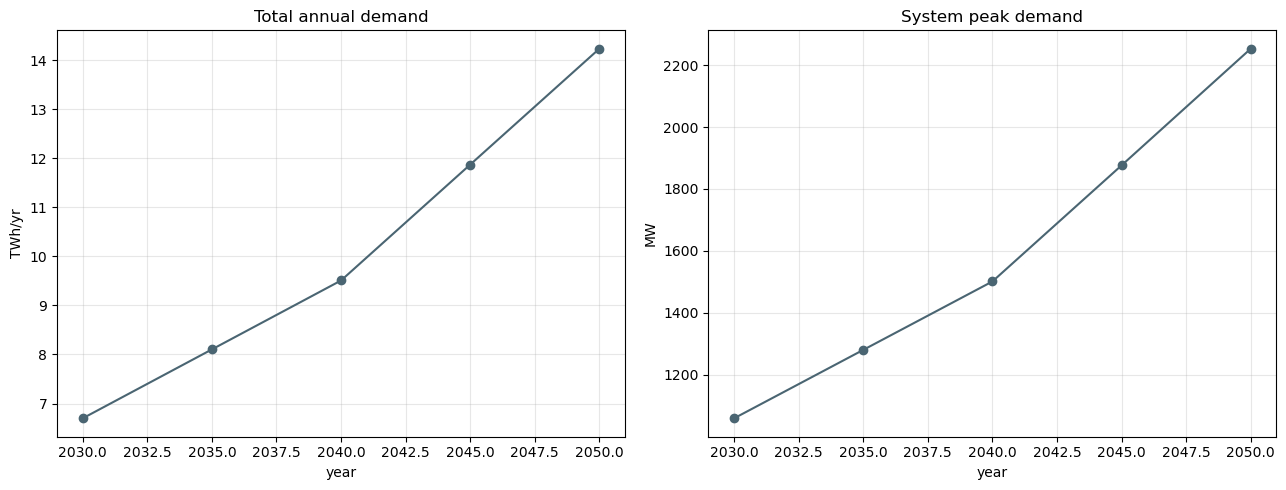

Implied CAGR 2030-2050: total demand 3.8%/yr, peak demand 3.8%/yr


In [11]:
demand_rows = []
for year in YEARS:
    n = networks.get(("bess", year, "vopt")) or networks.get(("no_bess", year, "vopt"))
    if n is None:
        continue
    load_t = n.loads_t.p_set.sum(axis=1)
    demand_rows.append(dict(year=year, total_TWh=load_t.sum() / 1e6, peak_MW=load_t.max()))

demand_df = pd.DataFrame(demand_rows).set_index("year")
display(demand_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(demand_df.index, demand_df.total_TWh, marker="o", color=COL["model"])
axes[0].set_title("Total annual demand"); axes[0].set_ylabel("TWh/yr"); axes[0].set_xlabel("year")
axes[1].plot(demand_df.index, demand_df.peak_MW, marker="o", color=COL["model"])
axes[1].set_title("System peak demand"); axes[1].set_ylabel("MW"); axes[1].set_xlabel("year")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/results_analysis/demand_growth.png", dpi=150)
plt.show()

growth_total = (demand_df.total_TWh.iloc[-1] / demand_df.total_TWh.iloc[0]) ** (1 / (demand_df.index[-1] - demand_df.index[0])) - 1
growth_peak = (demand_df.peak_MW.iloc[-1] / demand_df.peak_MW.iloc[0]) ** (1 / (demand_df.index[-1] - demand_df.index[0])) - 1
print(f"Implied CAGR {demand_df.index[0]}-{demand_df.index[-1]}: total demand {growth_total*100:.1f}%/yr, peak demand {growth_peak*100:.1f}%/yr")

**Reading this**: this is the demand-side driver behind every other finding in
this notebook -- the reserve-margin decline, the rising electricity-price tail, and
the flat-thermal/growing-solar+BESS capacity mix are all downstream of demand more
than doubling over 20 years while firm capacity barely moves.

## 1d. Energy mix through the years (vopt)

Actual **energy generated/discharged** (TWh/yr) by carrier -- distinct from the
installed-*capacity* chart above (MW nameplate, doesn't say how much each technology
actually gets used). Battery contributions are measured as energy **delivered to the
grid** (net of round-trip losses): existing battery uses `StorageUnit.p` (already net
at the grid connection); new-build battery uses `-Link.p1` on the discharger (the
AC-side output, not the larger battery-side withdrawal `Link.p0`, which would double
count the conversion loss).

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


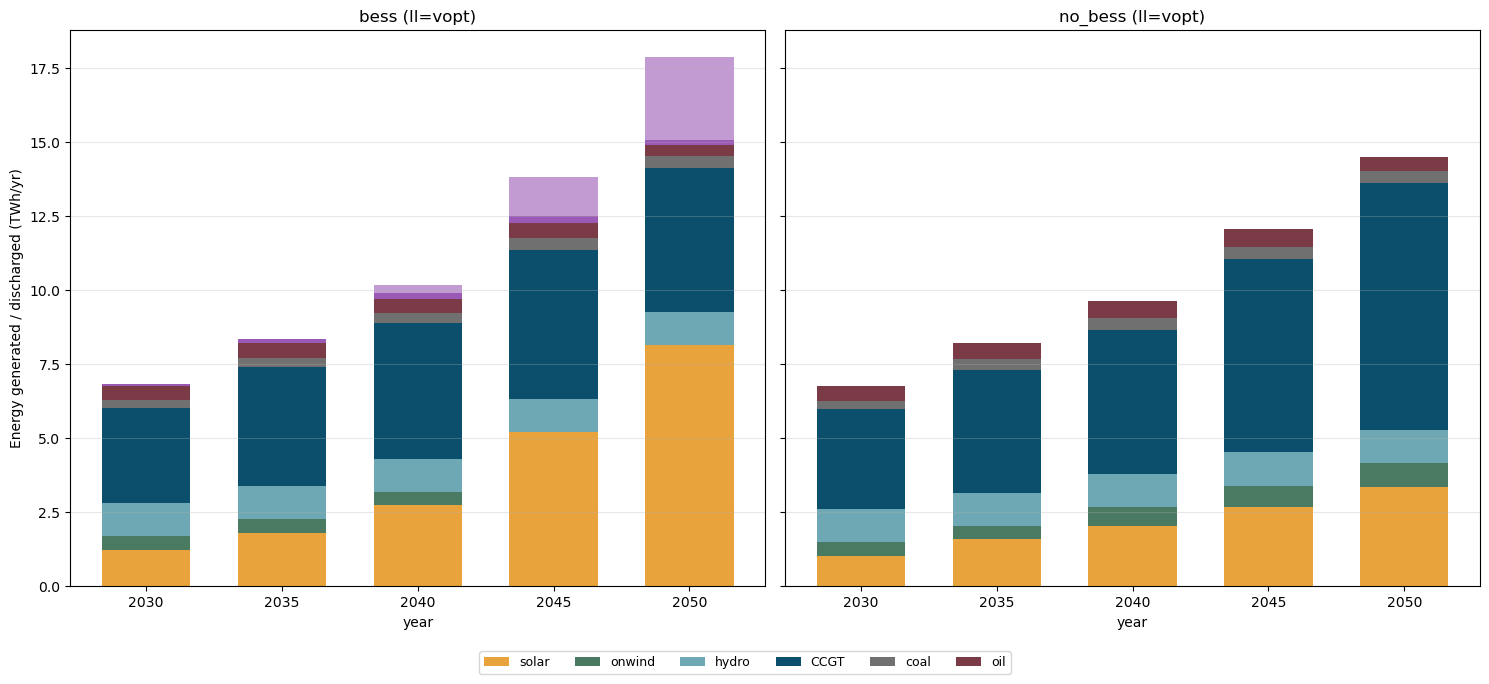

In [12]:
def energy_mix(n):
    gens = n.generators[n.generators.carrier.isin(GEN_CARRIERS)]
    dispatch = n.generators_t.p[gens.index].sum()  # MWh per generator, summed over year
    e = dispatch.groupby(gens.carrier).sum() / 1e6  # TWh per carrier

    hydro_su = n.storage_units[n.storage_units.carrier == "hydro"].index
    e["hydro"] = n.storage_units_t.p[hydro_su].clip(lower=0).sum().sum() / 1e6 if len(hydro_su) else 0.0

    batt_su = n.storage_units[n.storage_units.carrier == "battery"].index
    e["battery (existing)"] = n.storage_units_t.p[batt_su].clip(lower=0).sum().sum() / 1e6 if len(batt_su) else 0.0

    dischargers = n.links[n.links.carrier == "battery discharger"].index
    e["battery (new-build)"] = -n.links_t.p1[dischargers].sum().sum() / 1e6 if len(dischargers) else 0.0

    return e.reindex(CAP_ORDER).fillna(0.0)


fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
for ax, scen in zip(axes, SCENARIOS):
    data = {}
    for year in YEARS:
        n = networks.get((scen, year, "vopt"))
        if n is None:
            continue
        data[year] = energy_mix(n)
    mix_df = pd.DataFrame(data).T

    bottom = pd.Series(0.0, index=mix_df.index)
    for carrier in CAP_ORDER:
        if carrier not in mix_df.columns or mix_df[carrier].sum() == 0:
            continue
        ax.bar(mix_df.index.astype(str), mix_df[carrier], bottom=bottom,
               color=CAP_COLORS.get(carrier, "#999999"), label=carrier, width=0.65)
        bottom += mix_df[carrier]

    ax.set_title(f"{scen} (ll=vopt)")
    ax.set_xlabel("year")
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel("Energy generated / discharged (TWh/yr)")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=6, fontsize=9)
plt.tight_layout()
plt.savefig("figures/results_analysis/energy_mix.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading this against the capacity chart above**: solar's installed-capacity
share is much larger than its energy-mix share, because its capacity factor is only
~17% (Section on curtailment/capacity factor) -- lots of nameplate MW, comparatively
modest TWh. Thermal carriers show the opposite pattern: much smaller share of
capacity than of energy, since existing oil/CCGT/coal run at far higher utilisation
whenever dispatched. Comparing `bess` vs `no_bess` here shows how much energy the
battery is actually delivering, not just how much power capacity was built for it.

## 1e. BESS storage duration through the years (vopt)

Implied duration = energy capacity / power capacity (hours). New-build duration comes
from the optimizer's own `Store.e_nom_opt` / charger `Link.p_nom_opt` -- a genuine
sizing decision, re-solved fresh each year. Existing-battery duration should be a
fixed, capacity-weighted average of Senegal's real installed assets (~3.3h: a mix of
4h/2h/3h/3h units) -- **but a bug was just found and fixed in this session** (in
`attach_existing_batteries()`, `scripts/add_electricity.py`): the code checked for a
column named `"duration"` that never exists at that point in the pipeline (`
powerplantmatching`'s own `to_pypsa_names()` already renames it straight to
`"max_hours"` upstream), so the check always failed and silently overwrote every
asset's real duration with the config-wide 8h default instead. **None of the 10
solved networks in this batch reflect the fix yet** -- existing-battery duration
below is still the flat, wrong 8h artifact, shown for completeness but not to be
read as a real finding until the batch is re-solved.

,new_build_duration_h,existing_duration_h
year,,
2030,1.78,8.0
2035,2.17,8.0
2040,3.51,8.0
2045,5.11,8.0
2050,5.40,8.0


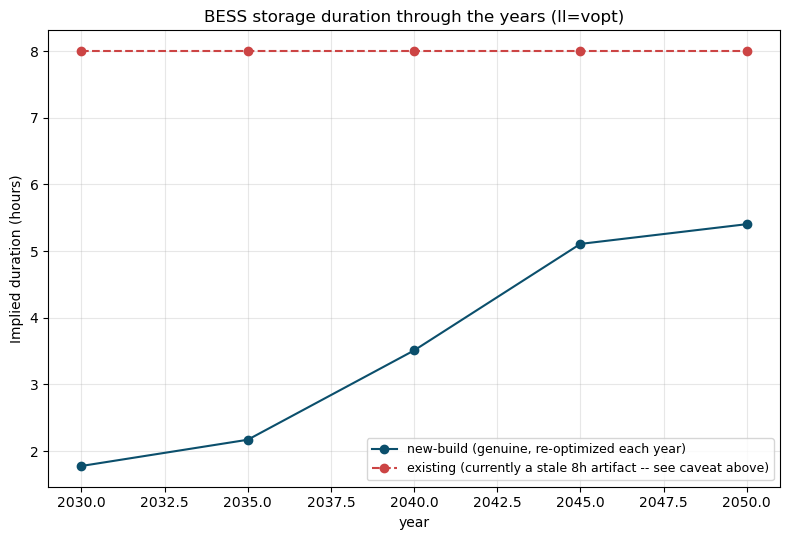

In [13]:
dur_rows = []
for year in YEARS:
    n = networks.get(("bess", year, "vopt"))
    if n is None:
        continue
    charger = n.links[n.links.carrier == "battery charger"]
    store = n.stores[n.stores.carrier == "battery"]
    new_duration = store.e_nom_opt.sum() / charger.p_nom_opt.sum() if charger.p_nom_opt.sum() > 0 else np.nan

    su = n.storage_units[n.storage_units.carrier == "battery"]
    exist_duration = (su.p_nom_opt * su.max_hours).sum() / su.p_nom_opt.sum() if su.p_nom_opt.sum() > 0 else np.nan

    dur_rows.append(dict(year=year, new_build_duration_h=new_duration, existing_duration_h=exist_duration))

dur_df = pd.DataFrame(dur_rows).set_index("year")
display(dur_df.round(2))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(dur_df.index, dur_df.new_build_duration_h, marker="o", color=COL["bess"], label="new-build (genuine, re-optimized each year)")
ax.plot(dur_df.index, dur_df.existing_duration_h, marker="o", color="#cc4444", linestyle="--",
        label="existing (currently a stale 8h artifact -- see caveat above)")
ax.set_ylabel("Implied duration (hours)")
ax.set_xlabel("year")
ax.set_title("BESS storage duration through the years (ll=vopt)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/results_analysis/bess_duration.png", dpi=150)
plt.show()

**Reading the new-build line**: duration lengthens from under 2 hours (2035,
the first year any new battery gets built at all) to over 5 hours by 2050. Early,
small battery builds are sized for short-duration balancing; by 2050, with solar
having grown to over 5,600 MW of mostly-midday nameplate capacity while the system
peak occurs in the evening (18:00, after solar output has mostly dropped off),
battery's role shifts toward genuinely shifting large volumes of midday solar into
the evening peak -- which needs longer duration, not just more power.

## 2. BESS input parameters through the years

CapEx, FOM, VOM (degradation), and efficiency are read straight from each year's
`config.LP_bess_{year}.yaml` override block (`costs.investment/FOM/VOM/efficiency`) --
this is always authoritative regardless of whether that config has been solved yet,
unlike a resolved cost-table CSV, which only reflects an override if it happened to
be generated *after* the config was last edited (a resolved-table lookup for 2045/2050
was caught returning stale pre-correction values from Aug 11 for exactly this reason).
Lifetime is **not** overridden anywhere in this project (DEA's own default trajectory
is used as-is), so it's read from whichever resolved cost table is available -- that
field is unaffected by config staleness since nothing here ever changes it. See
`BESS_cost_assumptions.pdf` for the full methodology and sourcing.

,year,technology,investment,FOM,VOM,efficiency,lifetime
0,2030,battery inverter,88437,2.0,15.70,0.85,10.0
1,2030,battery storage,78488,2.0,0.00,NaN,25.0
2,2035,battery inverter,75682,2.0,13.74,0.85,10.0
3,2035,battery storage,68696,2.0,0.00,NaN,27.5
4,2040,battery inverter,66962,2.0,12.59,0.85,10.0
5,2040,battery storage,62944,2.0,0.00,NaN,30.0
6,2045,battery inverter,55206,2.0,11.66,0.85,10.0
7,2045,battery storage,58311,2.0,0.00,NaN,30.0
8,2050,battery inverter,42787,2.0,10.70,0.85,10.0
9,2050,battery storage,53484,2.0,0.00,NaN,30.0


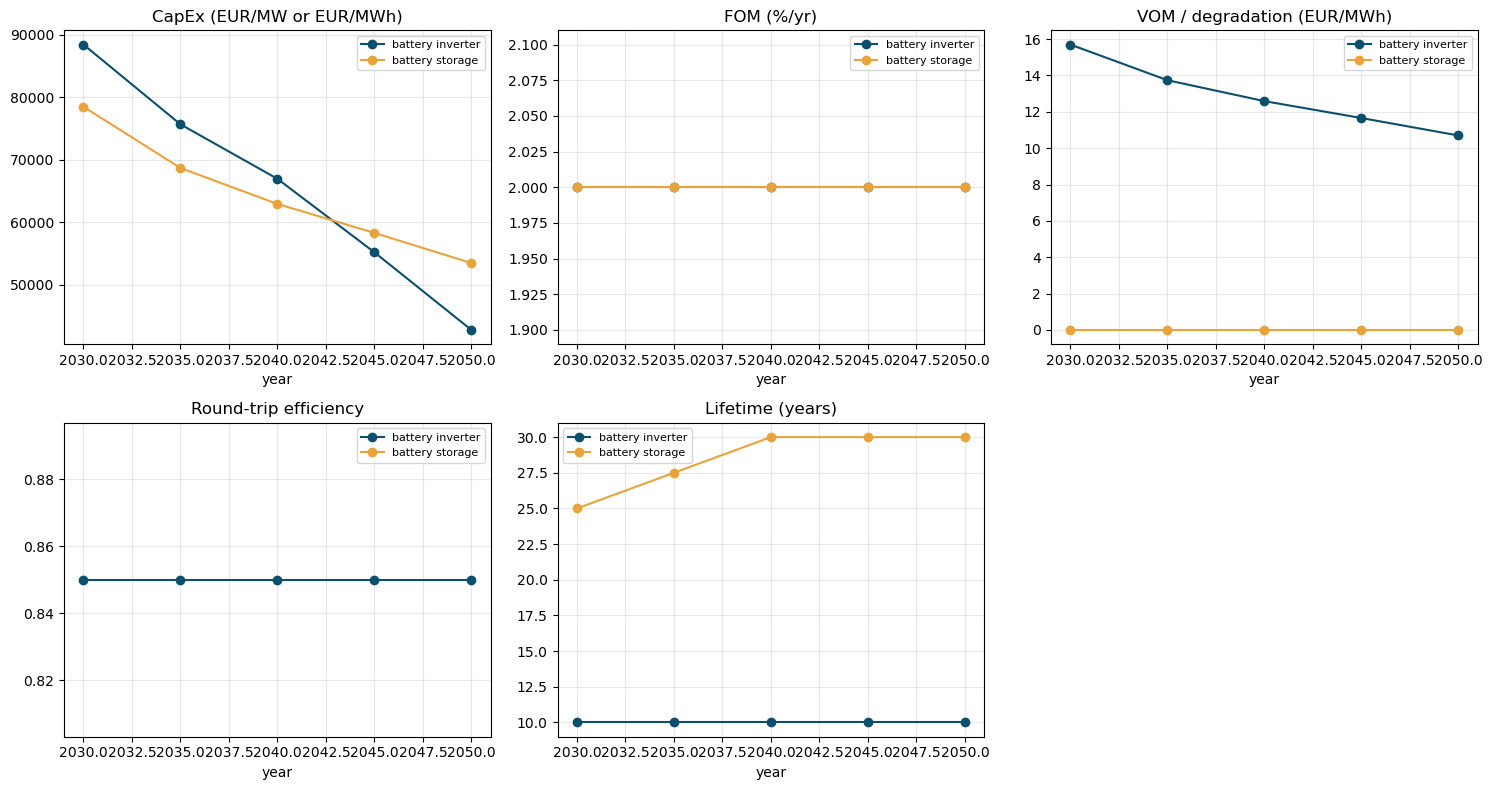

In [14]:
import yaml

rows = []
for year in YEARS:
    cfg = yaml.safe_load(open(f"config.LP_bess_{year}.yaml"))
    costs_cfg = cfg["costs"]

    lifetime = {"battery inverter": np.nan, "battery storage": np.nan}
    for path in (f"resources/LP_bess_{year}/costs_{year}_elec.csv",
                 f"resources/uc_bess_{year}/costs_{year}_elec.csv"):
        if os.path.exists(path):
            df = pd.read_csv(path, index_col=0)
            lifetime = {tech: df.loc[tech, "lifetime"] for tech in lifetime}
            break

    for tech in ("battery inverter", "battery storage"):
        rows.append(dict(
            year=year, technology=tech,
            investment=costs_cfg["investment"].get(tech),
            FOM=costs_cfg["FOM"].get(tech),
            VOM=costs_cfg["VOM"].get(tech, 0.0),
            efficiency=costs_cfg["efficiency"].get(tech, np.nan),
            lifetime=lifetime[tech],
        ))

bess_params = pd.DataFrame(rows)
display(bess_params)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = [("investment", "CapEx (EUR/MW or EUR/MWh)"), ("FOM", "FOM (%/yr)"),
           ("VOM", "VOM / degradation (EUR/MWh)"), ("efficiency", "Round-trip efficiency"),
           ("lifetime", "Lifetime (years)")]
for ax, (metric, ylabel) in zip(axes.flat, metrics):
    for tech, color in [("battery inverter", COL["bess"]), ("battery storage", COL["no_bess"])]:
        sub = bess_params[bess_params.technology == tech]
        ax.plot(sub.year, sub[metric], marker="o", color=color, label=tech)
    ax.set_title(ylabel); ax.set_xlabel("year"); ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig("figures/results_analysis/bess_input_params.png", dpi=150)
plt.show()

## 3. Curtailment through the years (vopt)

Curtailment = available VRE generation (`p_max_pu * p_nom_opt`) minus actual dispatch,
summed over the year, for solar and wind. Shown for the `bess` scenario; the `no_bess`
line is added automatically where available for comparison.

,bess,no_bess
2030,20682.287706,27857.039607
2035,45613.341718,58180.888699
2040,73724.172754,105242.806057
2045,115438.647493,142758.484303
2050,229848.671769,195365.122884


,bess,no_bess
2030,1.2,1.8
2035,2.0,2.8
2040,2.3,3.8
2045,2.2,4.0
2050,2.7,4.5


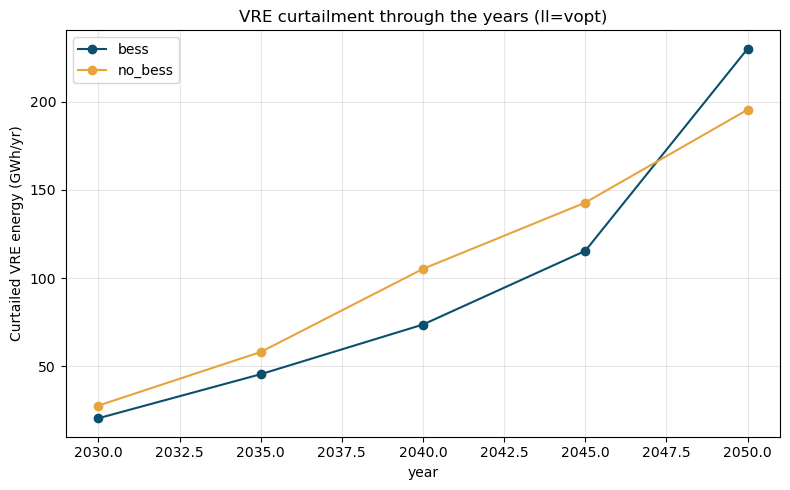

In [15]:
def curtailment_by_year(scenario):
    out = {}
    for year in YEARS:
        n = networks.get((scenario, year, "vopt"))
        if n is None:
            continue
        gens = n.generators[n.generators.carrier.isin(VRE_CARRIERS)]
        if len(gens) == 0:
            out[year] = 0.0
            continue
        available = (n.generators_t.p_max_pu[gens.index] * gens.p_nom_opt).sum().sum()
        dispatched = n.generators_t.p[gens.index].sum().sum()
        out[year] = max(available - dispatched, 0.0)
    return pd.Series(out, name=scenario)

curt = pd.concat([curtailment_by_year(s) for s in SCENARIOS], axis=1)
curt_pct = curt.copy()
for scen in SCENARIOS:
    for year in curt.index:
        n = networks.get((scen, year, "vopt"))
        if n is None:
            continue
        gens = n.generators[n.generators.carrier.isin(VRE_CARRIERS)]
        available = (n.generators_t.p_max_pu[gens.index] * gens.p_nom_opt).sum().sum()
        curt_pct.loc[year, scen] = 100 * curt.loc[year, scen] / available if available > 0 else np.nan

display(curt)
display(curt_pct.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
for scen in SCENARIOS:
    if curt[scen].notna().any():
        ax.plot(curt.index, curt[scen] / 1e3, marker="o", color=COL[scen], label=scen)
ax.set_ylabel("Curtailed VRE energy (GWh/yr)")
ax.set_xlabel("year")
ax.set_title("VRE curtailment through the years (ll=vopt)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/results_analysis/curtailment.png", dpi=150)
plt.show()

## 4. CO2 emissions through the years (vopt)

`sum(generator dispatch / efficiency * carrier CO2 intensity)` per year.

,bess,no_bess
2030,1.707157e+06,1.779963e+06
2035,2.022744e+06,2.147991e+06
2040,2.205295e+06,2.441573e+06
2045,2.442394e+06,2.995075e+06
2050,2.247221e+06,3.470336e+06


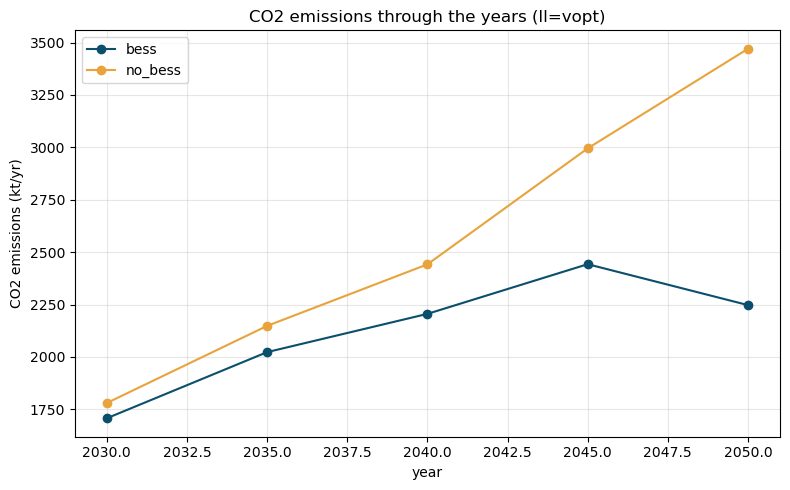

In [16]:
def co2_by_year(scenario):
    out = {}
    for year in YEARS:
        n = networks.get((scenario, year, "vopt"))
        if n is None:
            continue
        gens = n.generators[n.generators.carrier.isin(THERMAL_CARRIERS)]
        if len(gens) == 0:
            out[year] = 0.0
            continue
        dispatch = n.generators_t.p[gens.index].sum()  # MWh_e per generator, summed over year
        fuel_mwh_th = dispatch / gens.efficiency
        co2_t = (fuel_mwh_th * gens.carrier.map(n.carriers.co2_emissions)).sum()
        out[year] = co2_t
    return pd.Series(out, name=scenario)

co2 = pd.concat([co2_by_year(s) for s in SCENARIOS], axis=1)
display(co2)

fig, ax = plt.subplots(figsize=(8, 5))
for scen in SCENARIOS:
    if co2[scen].notna().any():
        ax.plot(co2.index, co2[scen] / 1e3, marker="o", color=COL[scen], label=scen)
ax.set_ylabel("CO2 emissions (kt/yr)")
ax.set_xlabel("year")
ax.set_title("CO2 emissions through the years (ll=vopt)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/results_analysis/co2_emissions.png", dpi=150)
plt.show()

## 5. Load shedding / reliability through the years (vopt)

The `load shedding` generator (unlimited capacity, ~1000 EUR/MWh marginal cost at
every bus) is the model's unserved-energy proxy. Its dispatched volume is Expected
Energy Not Served (EENS); the share of snapshots with any *material* shedding is a
Loss-of-Load-Expectation-style reliability metric.

Note: barrier-method LP solves leave a tiny numerical residual (~1e-6 MW, i.e.
microwatts) on the load-shedding generator in essentially every snapshot even when
nothing is genuinely unserved -- an EENS reading in the 0.01-0.1 MWh/yr range is that
noise floor, not real unserved demand. The LOLE-style metric below uses a 1 MW
threshold specifically to filter this out.

Expected Energy Not Served (MWh/yr):


,bess,no_bess
2030,0.019374,0.034899
2035,2.882741,6.920930
2040,0.350673,19.145388
2045,0.279559,651.252105
2050,0.046793,1400.790780


Hours-with-shedding, % of year (LOLE-style):


,bess,no_bess
2030,0.000,0.000
2035,0.023,0.023
2040,0.000,0.057
2045,0.000,0.194
2050,0.000,0.400


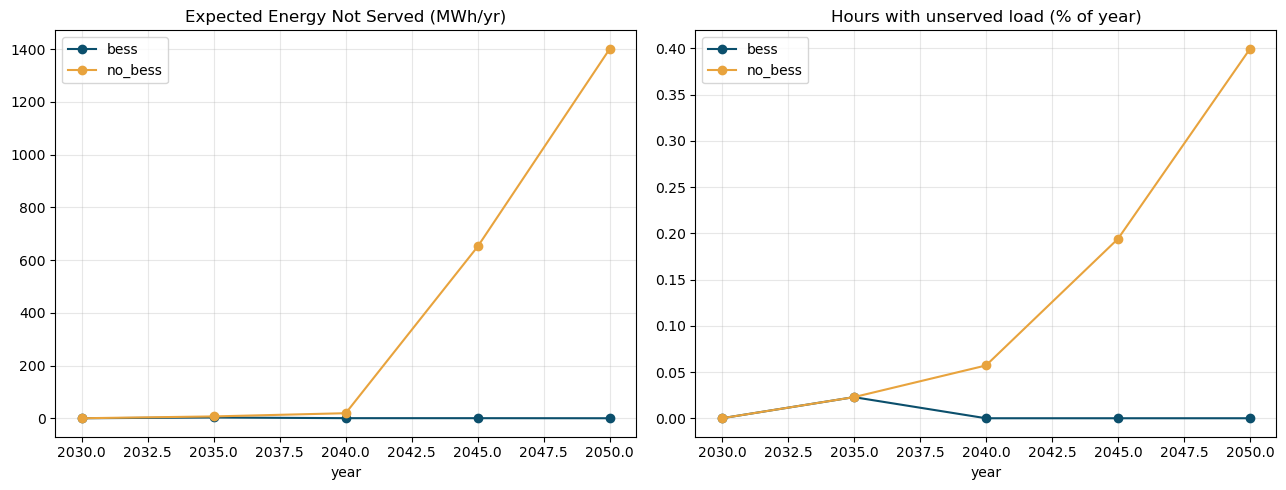

In [17]:
def shedding_by_year(scenario):
    eens, lole_pct = {}, {}
    for year in YEARS:
        n = networks.get((scenario, year, "vopt"))
        if n is None:
            continue
        ls = n.generators[n.generators.carrier == "load shedding"]
        if len(ls) == 0:
            eens[year] = 0.0; lole_pct[year] = 0.0
            continue
        shed_t = n.generators_t.p[ls.index].sum(axis=1)  # MW shed per snapshot, summed over buses
        eens[year] = shed_t.sum()  # MWh/yr (1h resolution)
        # 1 MW floor -- LP barrier-method solves leave a ~1e-6 MW numerical residual on every
        # snapshot even with zero real shedding; a tight threshold would flag that noise as
        # "100% of hours unserved". 1 MW is well above solver tolerance and well below any
        # plausible genuine shedding event on this system.
        lole_pct[year] = 100 * (shed_t > 1.0).sum() / len(n.snapshots)
    return pd.Series(eens, name=scenario), pd.Series(lole_pct, name=scenario)

eens_all, lole_all = {}, {}
for scen in SCENARIOS:
    e, l = shedding_by_year(scen)
    eens_all[scen] = e; lole_all[scen] = l
eens_df = pd.DataFrame(eens_all)
lole_df = pd.DataFrame(lole_all)

print("Expected Energy Not Served (MWh/yr):")
display(eens_df)
print("Hours-with-shedding, % of year (LOLE-style):")
display(lole_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for scen in SCENARIOS:
    if eens_df[scen].notna().any():
        axes[0].plot(eens_df.index, eens_df[scen], marker="o", color=COL[scen], label=scen)
        axes[1].plot(lole_df.index, lole_df[scen], marker="o", color=COL[scen], label=scen)
axes[0].set_title("Expected Energy Not Served (MWh/yr)"); axes[0].set_xlabel("year")
axes[1].set_title("Hours with unserved load (% of year)"); axes[1].set_xlabel("year")
for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/results_analysis/reliability.png", dpi=150)
plt.show()

## 5b. Reserve margin (vopt)

Methodology from de Weijer (TU Delft thesis, Appendix A.6):

$$RM_s = \frac{C_s^{firm} + C_s^{credited} - P_s^{peak}}{P_s^{peak}} \times 100$$

- $C_s^{firm}$ -- firm (dispatchable thermal) capacity at full nameplate: CCGT, OCGT,
  coal, oil, biomass.
- $C_s^{credited}$ -- VRE capacity discounted by a capacity credit factor. Per the
  source methodology, hydro is *also* capacity-credited here, not counted as firm.
- $P_s^{peak}$ -- peak system demand.
- Storage, transmission, demand itself, and load shedding are excluded from the
  capacity side entirely -- this is a generation-adequacy metric, not a
  delivery/grid-adequacy one.

**Two deviations from the source methodology, both deliberate:**

1. **No regional subsystem split.** de Weijer pools interconnected provinces and
   keeps isolated islands separate (Indonesia is an archipelago). Senegal's clustered
   network was checked directly (`networkx.number_connected_components`) and is a
   single connected component -- one national grid, no electrical islands -- so
   reserve margin is computed at the whole-system level, not per-region.
2. **Capacity credits are computed empirically from this model's own data, not
   reused from Indonesia.** The source's 0.22 (solar) / 0.36 (wind) / 0.55 (hydro)
   factors are Indonesia-calibrated and explicitly flagged by the source itself as
   not directly transferable, since capacity factor and timing correlation with peak
   demand are resource- and location-specific. Instead: for each technology, capacity
   credit = mean(dispatched output / installed capacity) during the hours where
   system demand is in its own top 5% for that year -- i.e., "how much of its
   nameplate does this resource actually deliver when Senegal's grid needs it most,"
   using the model's own weather-year-2013 profiles and its own demand shape.

,scenario,year,p_peak_MW,c_firm_MW,c_credited_MW,reserve_margin_pct,cc_solar,cc_onwind,cc_hydro
0,bess,2030,1059.69,1492.96,278.96,67.21,0.11,0.27,1.0
1,bess,2035,1280.55,1492.96,330.93,42.43,0.12,0.27,1.0
2,bess,2040,1501.41,1492.96,417.92,27.27,0.13,0.26,1.0
3,bess,2045,1876.18,1492.97,624.97,12.89,0.14,0.15,1.0
4,bess,2050,2252.72,1390.46,965.89,4.60,0.15,0.13,1.0
5,no_bess,2030,1059.69,1492.96,263.34,65.74,0.11,0.27,1.0
6,no_bess,2035,1280.55,1492.96,313.88,41.10,0.12,0.27,1.0
7,no_bess,2040,1501.41,1603.02,381.33,32.17,0.13,0.25,1.0
8,no_bess,2045,1876.18,1892.04,472.41,26.03,0.14,0.25,1.0
9,no_bess,2050,2252.72,2109.85,567.63,18.86,0.15,0.23,1.0


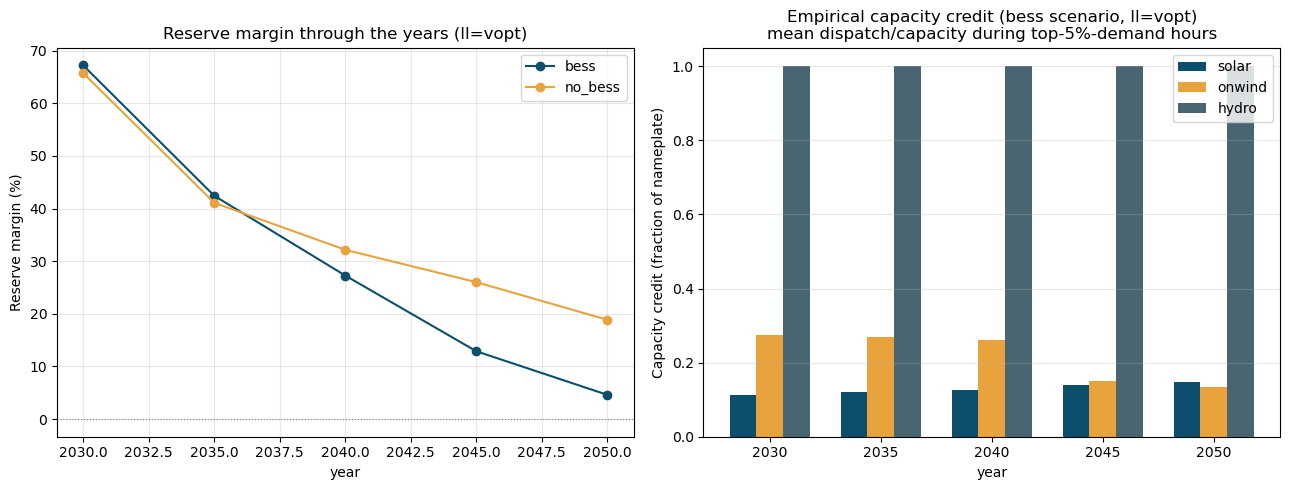

In [18]:
def capacity_credit(n, carrier, peak_hours):
    """Empirical capacity credit: mean(dispatch / installed capacity) during peak_hours."""
    if carrier == "hydro":
        assets = n.storage_units[n.storage_units.carrier == "hydro"]
        if len(assets) == 0 or assets.p_nom_opt.sum() == 0:
            return 0.0
        dispatch = n.storage_units_t.p[assets.index].clip(lower=0).sum(axis=1)
        installed = assets.p_nom_opt.sum()
    else:
        assets = n.generators[n.generators.carrier == carrier]
        if len(assets) == 0 or assets.p_nom_opt.sum() == 0:
            return 0.0
        dispatch = n.generators_t.p[assets.index].sum(axis=1)
        installed = assets.p_nom_opt.sum()
    return (dispatch.loc[peak_hours] / installed).mean()


def reserve_margin(n):
    load_t = n.loads_t.p_set.sum(axis=1)
    p_peak = load_t.max()
    peak_hours = load_t[load_t >= load_t.quantile(0.95)].index

    firm_carriers = ["CCGT", "OCGT", "coal", "oil", "biomass"]
    firm_gens = n.generators[n.generators.carrier.isin(firm_carriers)]
    c_firm = firm_gens.p_nom_opt.sum()

    credited_carriers = ["solar", "onwind", "hydro"]
    cc = {}
    c_credited = 0.0
    for carrier in credited_carriers:
        cred = capacity_credit(n, carrier, peak_hours)
        cc[carrier] = cred
        if carrier == "hydro":
            installed = n.storage_units[n.storage_units.carrier == "hydro"].p_nom_opt.sum()
        else:
            installed = n.generators[n.generators.carrier == carrier].p_nom_opt.sum()
        c_credited += installed * cred

    rm = 100 * (c_firm + c_credited - p_peak) / p_peak
    return dict(p_peak=p_peak, c_firm=c_firm, c_credited=c_credited, reserve_margin=rm,
                capacity_credits=cc)


rows = []
for scen in SCENARIOS:
    for year in YEARS:
        n = networks.get((scen, year, "vopt"))
        if n is None:
            continue
        r = reserve_margin(n)
        rows.append(dict(scenario=scen, year=year, p_peak_MW=r["p_peak"],
                          c_firm_MW=r["c_firm"], c_credited_MW=r["c_credited"],
                          reserve_margin_pct=r["reserve_margin"],
                          cc_solar=r["capacity_credits"]["solar"],
                          cc_onwind=r["capacity_credits"]["onwind"],
                          cc_hydro=r["capacity_credits"]["hydro"]))

rm_df = pd.DataFrame(rows)
display(rm_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for scen in SCENARIOS:
    sub = rm_df[rm_df.scenario == scen]
    if len(sub) > 0:
        axes[0].plot(sub.year, sub.reserve_margin_pct, marker="o", color=COL[scen], label=scen)

axes[0].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[0].set_title("Reserve margin through the years (ll=vopt)")
axes[0].set_ylabel("Reserve margin (%)"); axes[0].set_xlabel("year")
axes[0].legend(); axes[0].grid(alpha=0.3)

bess_sub = rm_df[rm_df.scenario == "bess"]
if len(bess_sub) > 0:
    width = 1.2
    axes[1].bar(bess_sub.year - width, bess_sub.cc_solar, width, label="solar", color=COL["bess"])
    axes[1].bar(bess_sub.year, bess_sub.cc_onwind, width, label="onwind", color=COL["no_bess"])
    axes[1].bar(bess_sub.year + width, bess_sub.cc_hydro, width, label="hydro", color=COL["model"])
axes[1].set_title("Empirical capacity credit (bess scenario, ll=vopt)\nmean dispatch/capacity during top-5%-demand hours")
axes[1].set_ylabel("Capacity credit (fraction of nameplate)"); axes[1].set_xlabel("year")
axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("figures/results_analysis/reserve_margin.png", dpi=150)
plt.show()

**Reading this**: a positive reserve margin means firm + credited capacity
exceeds peak demand by that percentage; negative means the system is formally
short of adequacy margin even before accounting for BESS or transmission
constraints (both deliberately excluded here, matching the source methodology).
Compare the empirical capacity credits (right panel) against Indonesia's
0.22/0.36/0.55 -- a large deviation would itself be a useful thesis finding about
how Senegal's solar/wind timing relative to its own demand peak differs from
Indonesia's.

## 6. Avoided fuel expenditure through the years (vopt)

`fuel expenditure = sum(generator dispatch / efficiency * fuel price)` per year, for
`no_bess` minus `bess` -- the fuel spend BESS displaces by absorbing cheap VRE and
discharging instead of running thermal plant.

,bess,no_bess
2030,1.757100e+08,1.814907e+08
2035,2.006340e+08,2.106996e+08
2040,2.154205e+08,2.374043e+08
2045,2.307208e+08,2.848224e+08
2050,2.022759e+08,3.121084e+08



Avoided fuel expenditure (no_bess - bess), EUR/yr:


2030    5.780662e+06
2035    1.006563e+07
2040    2.198373e+07
2045    5.410155e+07
2050    1.098324e+08
dtype: float64

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


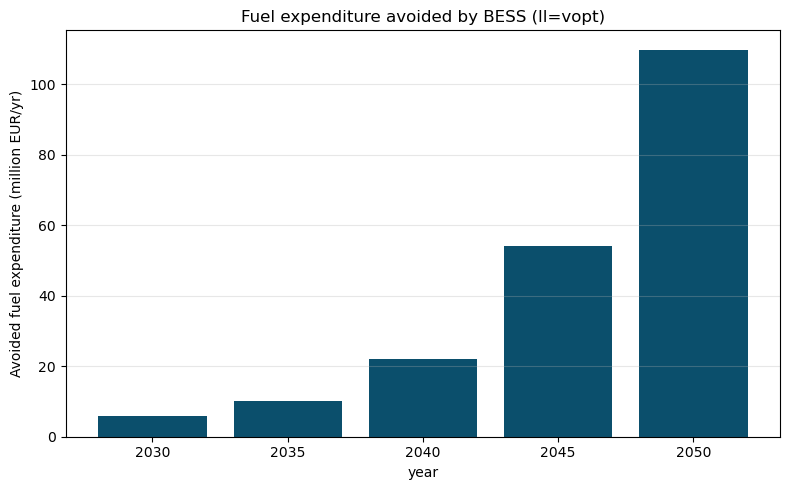

In [19]:
def fuel_spend_by_year(scenario):
    out = {}
    for year in YEARS:
        n = networks.get((scenario, year, "vopt"))
        if n is None:
            continue
        gens = n.generators[n.generators.carrier.isin(THERMAL_CARRIERS)]
        if len(gens) == 0:
            out[year] = 0.0
            continue
        for path in (f"resources/LP_{scenario}_{year}/costs_{year}_elec.csv",
                     f"resources/uc_{scenario}_{year}/costs_{year}_elec.csv"):
            if os.path.exists(path):
                costs = pd.read_csv(path, index_col=0)
                break
        else:
            continue
        dispatch = n.generators_t.p[gens.index].sum()  # MWh_e per generator/year
        fuel_mwh_th = dispatch / gens.efficiency
        fuel_price = gens.carrier.map(costs["fuel"])
        out[year] = (fuel_mwh_th * fuel_price).sum()
    return pd.Series(out, name=scenario)

fuel_spend = pd.concat([fuel_spend_by_year(s) for s in SCENARIOS], axis=1)
display(fuel_spend)

avoided = (fuel_spend["no_bess"] - fuel_spend["bess"]).dropna()
print("\nAvoided fuel expenditure (no_bess - bess), EUR/yr:")
display(avoided)

fig, ax = plt.subplots(figsize=(8, 5))
if len(avoided) > 0:
    ax.bar(avoided.index.astype(str), avoided / 1e6, color=COL["bess"])
ax.set_ylabel("Avoided fuel expenditure (million EUR/yr)")
ax.set_xlabel("year")
ax.set_title("Fuel expenditure avoided by BESS (ll=vopt)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("figures/results_analysis/avoided_fuel_expenditure.png", dpi=150)
plt.show()

## 7. Electricity price

- Mean (load-weighted) system electricity price through the years, `bess` vs `no_bess`.
- Probability density of nodal price, `bess` vs `no_bess`, 2050.
- Price during a sample week, `bess` vs `no_bess`.

All `ll=vopt`. Nodal `marginal_price` is the LP dual of the power-balance constraint —
only available now that these are pure LP solves (the earlier MILP runs couldn't
report duals).

,bess,no_bess
2030,31.28,31.24
2035,33.10,39.03
2040,33.41,42.44
2045,37.37,43.49
2050,36.19,45.00


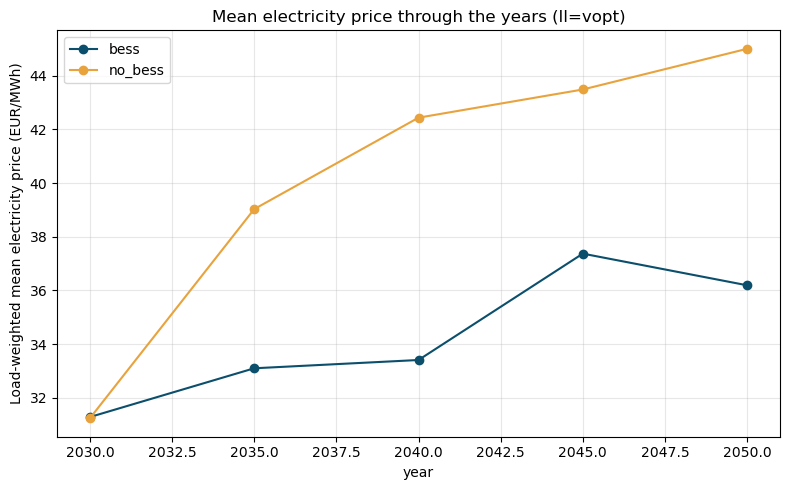

In [20]:
def load_weighted_price(n):
    load = n.loads_t.p_set.sum(axis=1)  # MW per snapshot, system-wide
    # bus-level load-weighted price, then system-wide load-weighted average
    bus_load = n.loads_t.p_set.T.groupby(n.loads.bus).sum().T
    common_buses = bus_load.columns.intersection(n.buses_t.marginal_price.columns)
    num = (bus_load[common_buses] * n.buses_t.marginal_price[common_buses]).sum(axis=1)
    den = bus_load[common_buses].sum(axis=1)
    price_t = num / den.replace(0, np.nan)
    return price_t

def mean_price_by_year(scenario):
    out = {}
    for year in YEARS:
        n = networks.get((scenario, year, "vopt"))
        if n is None:
            continue
        out[year] = load_weighted_price(n).mean()
    return pd.Series(out, name=scenario)

mean_price = pd.concat([mean_price_by_year(s) for s in SCENARIOS], axis=1)
display(mean_price.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
for scen in SCENARIOS:
    if mean_price[scen].notna().any():
        ax.plot(mean_price.index, mean_price[scen], marker="o", color=COL[scen], label=scen)
ax.set_ylabel("Load-weighted mean electricity price (EUR/MWh)")
ax.set_xlabel("year")
ax.set_title("Mean electricity price through the years (ll=vopt)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/results_analysis/mean_price.png", dpi=150)
plt.show()

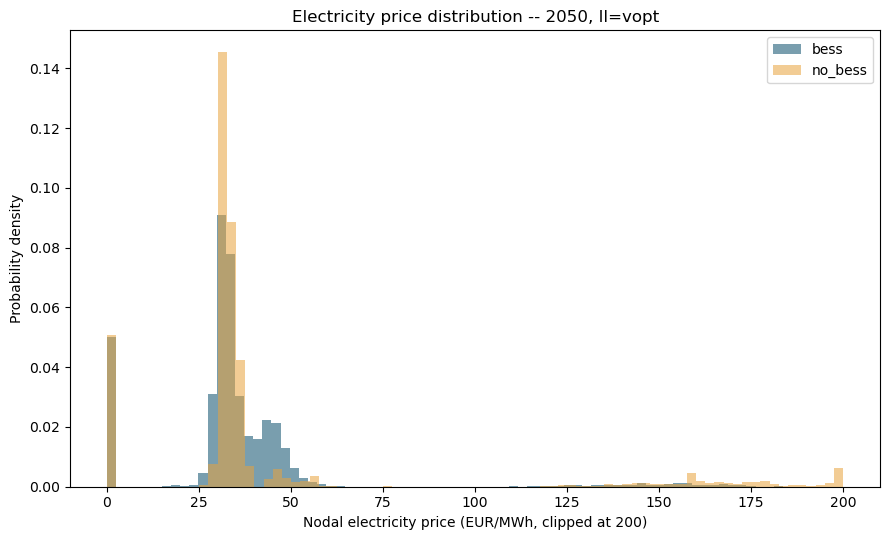

Saved figures/results_analysis/price_distribution_bess_vs_no_bess_2050.pdf


In [21]:
# --- PDF of nodal price, bess vs no_bess, 2050 ---
n_bess_2050 = networks.get(("bess", 2050, "vopt"))
n_nobess_2050 = networks.get(("no_bess", 2050, "vopt"))

if n_bess_2050 is None or n_nobess_2050 is None:
    print("Need both LP_bess_2050 and LP_no_bess_2050 (vopt) for this comparison -- not both available yet.")
else:
    price_bess = n_bess_2050.buses_t.marginal_price.values.flatten()
    price_nobess = n_nobess_2050.buses_t.marginal_price.values.flatten()
    # clip extreme load-shedding price spikes (~1000 EUR/MWh) for a readable density plot
    clip = 200
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.hist(np.clip(price_bess, None, clip), bins=80, density=True, alpha=0.55,
            color=COL["bess"], label="bess")
    ax.hist(np.clip(price_nobess, None, clip), bins=80, density=True, alpha=0.55,
            color=COL["no_bess"], label="no_bess")
    ax.set_xlabel(f"Nodal electricity price (EUR/MWh, clipped at {clip})")
    ax.set_ylabel("Probability density")
    ax.set_title("Electricity price distribution -- 2050, ll=vopt")
    ax.legend()
    plt.tight_layout()
    plt.savefig("figures/results_analysis/price_pdf_2050.png", dpi=150)
    plt.show()

    # standalone PDF file, as requested
    fig.savefig("figures/results_analysis/price_distribution_bess_vs_no_bess_2050.pdf")
    print("Saved figures/results_analysis/price_distribution_bess_vs_no_bess_2050.pdf")

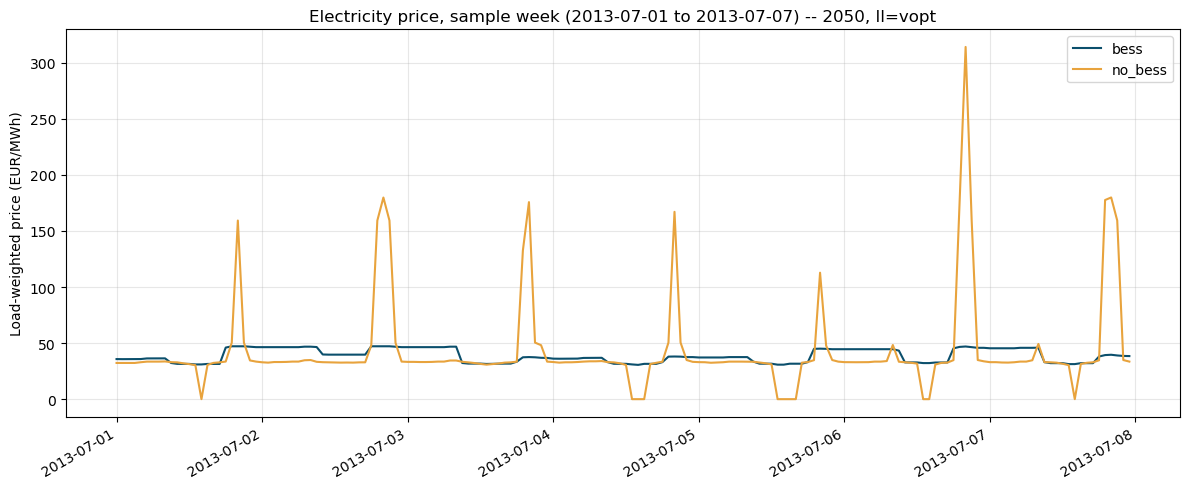

In [22]:
# --- Price during a sample week, bess vs no_bess (vopt) ---
if n_bess_2050 is None or n_nobess_2050 is None:
    print("Need both LP_bess_2050 and LP_no_bess_2050 (vopt) -- not both available yet.")
else:
    week_start, week_end = "2013-07-01", "2013-07-07"
    p_bess = load_weighted_price(n_bess_2050).loc[week_start:week_end]
    p_nobess = load_weighted_price(n_nobess_2050).loc[week_start:week_end]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(p_bess.index, p_bess.values, color=COL["bess"], label="bess")
    ax.plot(p_nobess.index, p_nobess.values, color=COL["no_bess"], label="no_bess")
    ax.set_ylabel("Load-weighted price (EUR/MWh)")
    ax.set_title(f"Electricity price, sample week ({week_start} to {week_end}) -- 2050, ll=vopt")
    ax.legend(); ax.grid(alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig("figures/results_analysis/price_sample_week_2050.png", dpi=150)
    plt.show()

## 8. Total system cost — bess vs no_bess, vopt vs v1.0

`network.objective + network.objective_constant` (the objective is defined relative
to the constant, which captures the fixed cost of already-existing/non-extendable
assets).

scenario   bess        no_bess       
ll         v1.0   vopt    v1.0   vopt
year                                 
2030      400.0  400.0   401.4  401.4
2035      438.8  438.8   444.3  444.3
2040      478.0  478.0   500.1  499.3
2045      549.4  549.4   605.0  597.7
2050      598.1  598.1   717.4  674.2

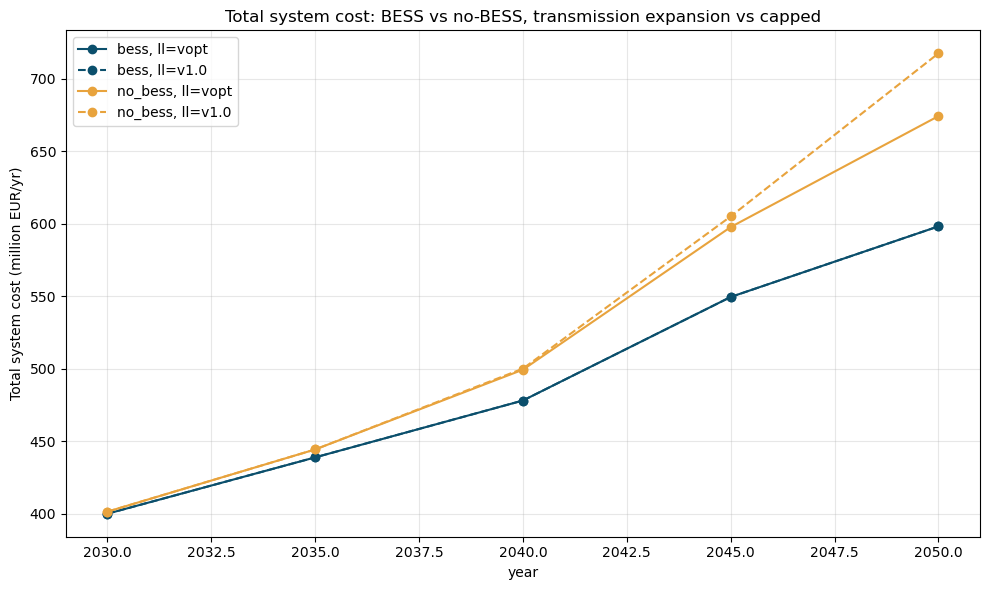

In [23]:
rows = []
for scen in SCENARIOS:
    for year in YEARS:
        for ll in LL:
            n = networks.get((scen, year, ll))
            if n is None:
                continue
            rows.append(dict(scenario=scen, year=year, ll=ll,
                              total_cost=n.objective + n.objective_constant))
cost_df = pd.DataFrame(rows)
cost_pivot = cost_df.pivot_table(index="year", columns=["scenario", "ll"], values="total_cost")
display((cost_pivot / 1e6).round(1))  # million EUR

fig, ax = plt.subplots(figsize=(10, 6))
styles = {"vopt": "-", "v1.0": "--"}
for scen in SCENARIOS:
    for ll in LL:
        if (scen, ll) in cost_pivot.columns:
            ax.plot(cost_pivot.index, cost_pivot[(scen, ll)] / 1e6, marker="o",
                    linestyle=styles[ll], color=COL[scen], label=f"{scen}, ll={ll}")
ax.set_ylabel("Total system cost (million EUR/yr)")
ax.set_xlabel("year")
ax.set_title("Total system cost: BESS vs no-BESS, transmission expansion vs capped")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/results_analysis/total_system_cost.png", dpi=150)
plt.show()

## 9. At what price does BESS + solar push thermal out of the dispatch? (vopt)

For each year, every hourly snapshot is a (system price, thermal generation) point.
Sorting by price gives an implied "merit-order crossover": the price level below
which thermal generation is essentially never dispatched, because solar + battery
discharge cover load more cheaply.

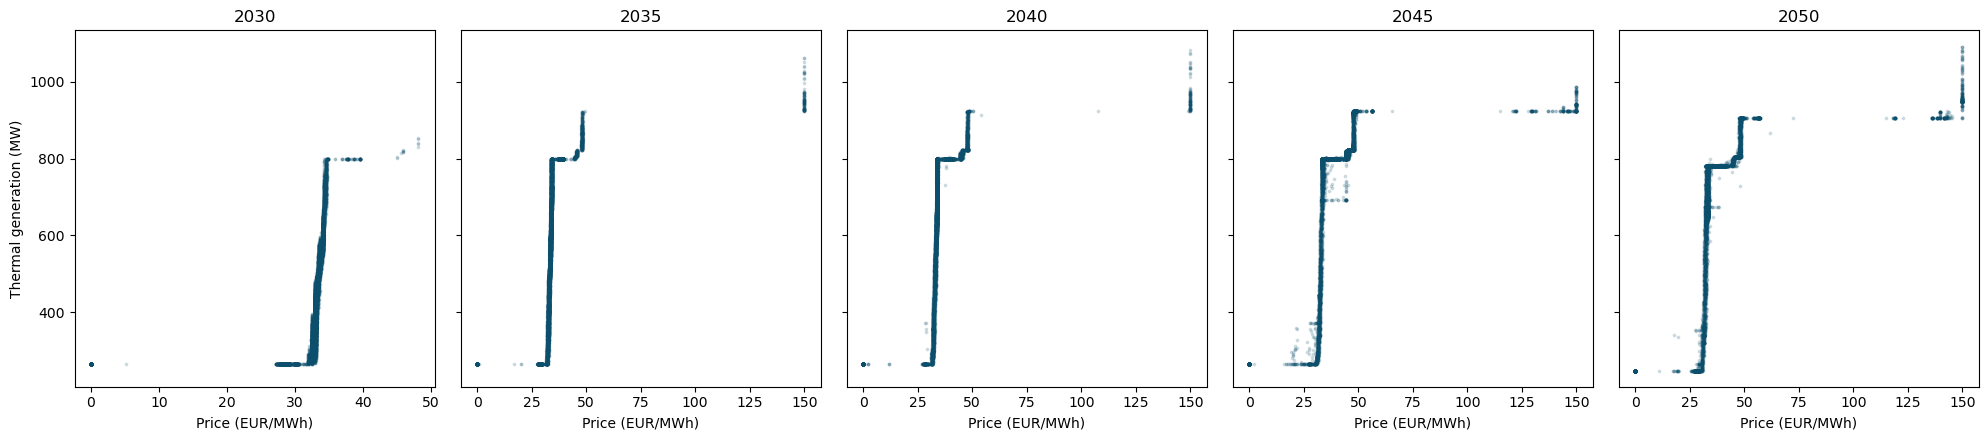

Approximate price below which thermal generation drops out (10th pct. of price when thermal > 5% of fleet capacity):


2030    28.7
2035    29.6
2040    27.5
2045     0.0
2050     0.0
Name: crossover_price_eur_mwh, dtype: float64

In [24]:
fig, axes = plt.subplots(1, len(YEARS), figsize=(4 * len(YEARS), 4.5), sharey=True)
if len(YEARS) == 1:
    axes = [axes]

crossover_price = {}
for ax, year in zip(axes, YEARS):
    n = networks.get(("bess", year, "vopt"))
    if n is None:
        ax.set_title(f"{year}\n(not available)")
        ax.axis("off")
        continue
    price_t = load_weighted_price(n)
    thermal_gens = n.generators[n.generators.carrier.isin(THERMAL_CARRIERS)]
    thermal_t = n.generators_t.p[thermal_gens.index].sum(axis=1) if len(thermal_gens) else pd.Series(0, index=n.snapshots)

    ax.scatter(price_t.clip(upper=150), thermal_t, s=3, alpha=0.15, color=COL["bess"])
    ax.set_title(str(year))
    ax.set_xlabel("Price (EUR/MWh)")

    # crossover: lowest price bin where thermal generation becomes consistently non-trivial
    df = pd.DataFrame({"price": price_t, "thermal": thermal_t}).dropna()
    if len(df) > 0 and df["thermal"].max() > 0:
        threshold = 0.05 * thermal_gens.p_nom_opt.sum()  # 5% of thermal fleet capacity
        active = df[df["thermal"] > threshold]
        crossover_price[year] = active["price"].quantile(0.10) if len(active) > 0 else np.nan
    else:
        crossover_price[year] = np.nan

axes[0].set_ylabel("Thermal generation (MW)")
plt.tight_layout()
plt.savefig("figures/results_analysis/price_vs_thermal_dispatch.png", dpi=150)
plt.show()

print("Approximate price below which thermal generation drops out (10th pct. of price when thermal > 5% of fleet capacity):")
display(pd.Series(crossover_price, name="crossover_price_eur_mwh").round(1))

**Reading this**: the scatter shows, for every hour of the year, how much thermal
generation ran at that price. A clean model would show a sharp knee -- thermal
essentially off below some price, and filling in above it as solar/battery are
exhausted. The `crossover_price` table gives an approximate EUR/MWh figure for that
knee per year; watch whether it moves as BESS gets cheaper and more of it gets built
(2030 -> 2050), which would indicate solar+BESS is capturing a growing share of the
merit order at the low-price end.